<a href="https://colab.research.google.com/github/jungeun1228/2026_02_Tox21_ML_DL/blob/main/2026_Tox21_Traditional_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tox21 Data challenge

- 12 assay endpoints; "1" means active, "0" means inactive
- Link for the challenge: https://tripod.nih.gov/tox21/challenge/data.jsp#

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 22.8 MB/s eta 0:00:00


In [ ]:
# Download Tox21 dataset from Tox21 challenge website
!wget -O tox21_data.zip "https://tripod.nih.gov/tox21/challenge/download?id=tox21_10k_data_allsdf&sec="
!unzip tox21_data.zip
!ls

--2026-04-05 08:49:13--  https://tripod.nih.gov/tox21/challenge/download?id=tox21_10k_data_allsdf&sec=
Resolving tripod.nih.gov (tripod.nih.gov)... 128.231.19.105
Connecting to tripod.nih.gov (tripod.nih.gov)|128.231.19.105|:443... connected.
HTTP request sent, awaiting response... 200 
Length: unspecified [application/zip]
Saving to: ‘tox21_data.zip’

tox21_data.zip          [  <=>               ]   2.50M  11.0MB/s    in 0.2s    

2026-04-05 08:49:14 (11.0 MB/s) - ‘tox21_data.zip’ saved [2627177]

Archive:  tox21_data.zip
  inflating: tox21_10k_data_all.sdf  
sample_data  tox21_10k_data_all.sdf  tox21_data.zip


# SDF file exploration

SMILES of the molecule: C[n+]1c2cc(N)ccc2cc2ccc(N)cc21.Nc1ccc2cc3ccc(N)cc3nc2c1.[Cl-]
Properties of the molecule:
Formula : C27H25ClN6
FW : 468.9806 (35.4535+224.2805+209.2465)
DSSTox_CID : 25848
SR-HSE : 0


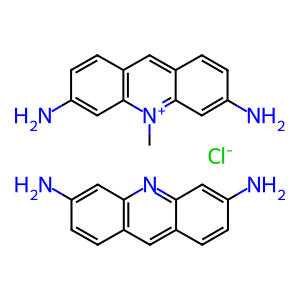

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

sdf_path = "tox21_10k_data_all.sdf"
supplier = Chem.SDMolSupplier(sdf_path)
mol = supplier[0]  # first molecule

# 1. Read SDF - print each molecule as SMILES
print(f"SMILES of the molecule: {Chem.MolToSmiles(mol)}")

# 2. Read property - activity, name
print("Properties of the molecule:")
for prop in mol.GetPropNames():
    print(prop,":", mol.GetProp(prop))

# 3. Show molecule structure image
Draw.MolToImage(mol)

# Data exploration

## Additional info about input
- canonicalization: Prevents the issue where the same molecule is represented by different SMILES strings; while not strictly mandatory, it is considered a near-standard level of basic preprocessing.
- tautomer / protonation state / salt / stereochemistry: These are "context-dependent"; in a baseline model, they are generally not altered excessively.
 - Canonicalization deals with standardization of representation, whereas handling tautomers and protonation states addresses the issue of defining chemical identity.

(1) Tautomer (e.g., keto-enol forms) - Cases where the molecules are identical but differ only in their structural form; typically left unchanged in a baseline model (implementation is somewhat complex, policies vary by dataset, and mishandling can lead to information loss).

(2) Protonation state (pH status): varies depending on assay conditions (pH); typically left unchanged (baseline)

(3) Salt removal (e.g., HCl, Na+) - performed quite frequently (high importance); commonly done even for baseline models; "drug + salt" forms represent the same chemical compound but may appear as distinct entries in the data  
e.g., from rdkit.Chem import rdMolStandardize

cleaner = rdMolStandardize.LargestFragmentChooser()
mol = cleaner.choose(mol)  

(4) Stereochemistry - typically left unchanged (default)

Recommended Pipeline: SDF → Mol → (Optional) Salt Removal → Canonical SMILES → DataFrame → Deduplication →  Split


In [ ]:
from rdkit import Chem
import pandas as pd

sdf_path = "tox21_10k_data_all.sdf"
supplier = Chem.SDMolSupplier(sdf_path)

rows = []

for i, mol in enumerate(supplier):
    if mol is None:   # when parsing fails
        rows.append({
            "idx": i,
            "status": "parse_failed"
        })
        continue

    try:
        # bring all SDF property
        props = {k: mol.GetProp(k) for k in mol.GetPropNames()} # key-value dictionary forms: bring as raw format cf. props = mol.GetPropsAsDict() - Retrieved as a numeric sequence
        # canonical smiles
        canonical_smiles = Chem.MolToSmiles(mol, canonical=True)

        row = {
            "idx": i,
            "canonical_smiles": canonical_smiles,
            "status": "ok",
        }

        # gather properties
        row.update(props)  # combine dict
        rows.append(row)  # add row into the list

    except Exception as e:
        rows.append({
            "idx": i,
            "status": f"failed: {str(e)}"
        })

df = pd.DataFrame(rows)
df.head()

[08:49:15] Explicit valence for atom # 3 Cl, 1, is greater than permitted
[08:49:15] ERROR: Could not sanitize molecule ending on line 21572
[08:49:15] ERROR: Explicit valence for atom # 3 Cl, 1, is greater than permitted
[08:49:17] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 1 ignored.
[08:49:17] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 1 ignored.
[08:49:17] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 6 ignored.
[08:49:17] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 6 ignored.
[08:49:20] Explicit valence for atom # 3 Cl, 1, is greater than permitted
[08:49:20] ERROR: Could not sanitize molecule ending on line 446665
[08:49:20] ERROR: Explicit valence for atom # 3 Cl, 1, is greater than permitted
[08:49:22] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[08:49:22] ERROR: Could not sanitize molecule ending on l

,idx,canonical_smiles,status,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD
0,0,C[n+]1c2cc(N)ccc2cc2ccc(N)cc21.Nc1ccc2cc3ccc(N...,ok,C27H25ClN6,468.9806 (35.4535+224.2805+209.2465),25848,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,O=C([O-])c1ccccc1-c1c2cc(Br)c(=O)c(Br)c-2oc2c(...,ok,C20H6Br4Na2O5,691.8542 (645.8757+22.9892+22.9892),5234,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,CO[C@@H]1[C@@H](OC)[C@H](C)[C@@](O)(CC(=O)[O-]...,ok,C47H83NO17,934.1584 (916.1205+18.0379),28909,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccccc2)c...,ok,C52H54N4O12,927.0048 (329.4575+89.0275+89.0275+329.4575+90...,5513,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,CC(=O)O.CCNC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(=...,ok,C66H87N17O14,1342.5025 (1282.4505+60.0520),26683,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df[df["status"] != "ok"]

,idx,canonical_smiles,status,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD
281,281,NaN,parse_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5588,5588,NaN,parse_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7626,7626,NaN,parse_failed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_ok = df[df["status"] == "ok"].copy()
print(f"Original molecules: {len(df)} -> Molecules with normal SMILES: {len(df_ok)}")

print(f"Complete duplicates: {df_ok.drop(columns=["idx"]).duplicated().sum()}")

df_dedup = df_ok.drop(columns=["idx"]).drop_duplicates().reset_index(drop=True)
print(f"Molecules after removing complete duplicates: {len(df_dedup)}")


print(f"Duplicates with the same SMILES: {df_ok.duplicated(subset="canonical_smiles").sum()}")

Original molecules: 11764 -> Molecules with normal SMILES: 11761
Complete duplicates: 281
Molecules after removing complete duplicates: 11480
Duplicates with the same SMILES: 3720


# Check Duplicate with the same SMILES and combine them into single data as follows
(Complete duplicates: 281 were removed above)

Duplicates with the same SMILES: For the same endpoint, take activity values as below.
- NaN + NaN → NaN
- NaN + 0 → 0 / NaN + 1 → 1
- 0 + 1 → **NaN** (conflict!)

In [ ]:
# Check duplicates
print(f"Duplicates with the same SMILES: {df_ok.duplicated(subset="canonical_smiles").sum()}")

Duplicates with the same SMILES: 3720


In [ ]:
dup_smiles_rows = df[df["canonical_smiles"].duplicated(keep=False)].sort_values("canonical_smiles")
dup_smiles_rows.head(20)

,idx,canonical_smiles,status,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD
687,687,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,ok,C17H22BrNO4,384.2649 (303.3529+80.9119),25419,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4455,4455,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,ok,C17H22BrNO4,384.2649 (303.3529+80.9119),25419,NaN,0,NaN,0,0,0,0,NaN,0,0,0,0
5647,5647,Br.CN1[C@@H]2CC[C@H]1C[C@@H](OC(=O)C(O)c1ccccc...,ok,C16H22BrNO3,356.2548 (275.3428+80.9119),25099,NaN,1,NaN,0,0,0,0,0,0,0,0,0
1011,1011,Br.CN1[C@@H]2CC[C@H]1C[C@@H](OC(=O)C(O)c1ccccc...,ok,C16H22BrNO3,356.2548 (275.3428+80.9119),25099,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5648,5648,Br.CN1[C@@H]2CC[C@H]1C[C@@H](OC(=O)C(O)c1ccccc...,ok,C16H22BrNO3,356.2548 (275.3428+80.9119),25099,NaN,0,NaN,0,0,0,0,0,0,0,0,0
5651,5651,Br.CN1[C@@H]2C[C@@H](OC(=O)[C@H](CO)c3ccccc3)C...,ok,C17H22BrNO4,384.2649 (303.3529+80.9119),12029,NaN,0,NaN,0,0,0,0,0,0,0,0,0
10210,10210,Br.CN1[C@@H]2C[C@@H](OC(=O)[C@H](CO)c3ccccc3)C...,ok,C17H22BrNO4,384.2649 (303.3529+80.9119),12029,0,0,0,0,0,0,0,0,0,0,0,0
1012,1012,Br.CN1[C@@H]2C[C@@H](OC(=O)[C@H](CO)c3ccccc3)C...,ok,C17H22BrNO4,384.2649 (303.3529+80.9119),12029,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5649,5649,Br.CN1[C@@H]2C[C@@H](OC(=O)[C@H](CO)c3ccccc3)C...,ok,C17H28BrNO7,438.3107 (80.9119+18.0153+18.0153+18.0153+303....,1258,NaN,0,NaN,0,0,0,0,1,0,0,0,0
9472,9472,Br.CN1[C@@H]2C[C@@H](OC(=O)[C@H](CO)c3ccccc3)C...,ok,C17H28BrNO7,438.3107 (80.9119+18.0153+18.0153+18.0153+303....,1258,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
import numpy as np
import pandas as pd

def duplicate_combine(series):
    # turn into numeric values ("0","1")
    vals = pd.to_numeric(series, errors="coerce").dropna().unique() # 숫자로 변환하다가 실패하면: 에러발생대신, NaN으로 바꿔라

    if len(vals) == 0:
        return np.nan          # all NaN
    if len(vals) == 1:
        return int(vals[0])    # 0 or 1
    else:
        return np.nan          # both 0 and 1 → conflict

In [ ]:
df_ok.columns[6:]

Index(['SR-HSE', 'NR-AR', 'SR-ARE', 'NR-Aromatase', 'NR-ER-LBD', 'NR-AhR',
       'SR-MMP', 'NR-ER', 'NR-PPAR-gamma', 'SR-p53', 'SR-ATAD5', 'NR-AR-LBD'],
      dtype='object')

In [ ]:
# Apply to the endpoint_column VER 1 - simple & practical --> practice!

# 1-1. Create aggregation dict & use meta info from first row for aggregation
meta_column = ['idx', 'canonical_smiles', 'Formula', 'FW', 'DSSTox_CID']  # excluded 'status'
agg_dict = {col: "first" for col in meta_column}

# 1-2. aggregation endpoint info - use duplicate_combine function
endpoint_column = df_ok.columns[6:]
for col in endpoint_column:
    agg_dict[col] = duplicate_combine
# 2. grouping based on smiles
df_grouped = df_ok.groupby("canonical_smiles", as_index=False).agg(agg_dict)

print(df_ok.shape, "→", df_grouped.shape)

(11761, 18) → (8041, 17)


In [ ]:
df_grouped

,idx,canonical_smiles,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD
0,687,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,C17H22BrNO4,384.2649 (303.3529+80.9119),25419,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
1,5652,Br.CC(N)Cc1ccc(O)cc1,C9H14BrNO,232.1176 (80.9119+151.2056),25961,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3557,Br.CCCCCCCCN1C=CN(C)C1,C12H25BrN2,277.2443 (196.3324+80.9119),29288,0.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0
3,10209,Br.CCCCN1C=CN(C)C1,C8H17BrN2,221.1380 (140.2260+80.9119),29321,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10207,Br.CCCN1C=CN(C)C1,C7H15BrN2,207.1114 (126.1995+80.9119),29320,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8036,10353,c1coc(Cn2cccc2)c1,C9H9NO,147.1739,27663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8037,5295,c1csc(-c2ccc(-c3cccs3)s2)c1,C12H8S3,248.3869,21206,1.0,1.0,1.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,1.0,1.0
8038,5677,c1csc(C2(N3CCCCC3)CCCCC2)c1,C15H23NS,249.4148,26168,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8039,7302,c1csc(SSc2cccs2)c1,C8H6S4,230.3932,27476,1.0,0.0,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0


In [ ]:
# # Apply to the endpoint_column  VER 2 - more straightforward

# rows = []

# for smiles, group in df.groupby("smiles"):
#     row = {"smiles": smiles}

#     # 1. 타깃 컬럼 처리
#     for col in endpoint_column:
#         row[col] = duplicate_combine(group[col])

#     # 2. 메타 컬럼 처리
#     for col in ["Formula", "FW", "DSSTox_CID"]:
#         row[col] = group[col].iloc[0]

#     rows.append(row)

# df_grouped = pd.DataFrame(rows)

# print(df.shape, "→", df_grouped.shape)

In [ ]:
# Filter out data with only NaN values for all endpoints (e.g., data only with chemical information)
print(f"Before filtering: df_grouped {df_grouped.shape}")
df_filtered = df_grouped.dropna(subset=endpoint_column, how="all")
print(f"After filtering: df_filtered {df_filtered.shape}")
print("It turned out that all chemicals has toxicity data from at least one endpoint.")

Before filtering: df_grouped (8041, 17)
After filtering: df_filtered (8041, 17)
It turned out that all chemicals has toxicity data from at least one endpoint.


# Data exploration

In [ ]:
overview = pd.DataFrame({
    "dtype": df_filtered.dtypes.astype(str),
    "non_null_count": df_filtered.notna().sum(),
    "count_0": (df_filtered==0).sum(),
    "count_1": (df_filtered==1).sum()

})
overview["count_sum"] = overview["count_0"] + overview["count_1"]
# overview
overview["non_null_count = count_sum ?"] = overview["non_null_count"] == overview["count_sum"]

overview.sort_values(by="non_null_count", ascending=False)

,dtype,non_null_count,count_0,count_1,count_sum,non_null_count = count_sum ?
idx,int64,8041,1,1,2,False
canonical_smiles,object,8041,0,0,0,False
Formula,object,8041,0,0,0,False
FW,object,8041,0,0,0,False
DSSTox_CID,object,8041,0,0,0,False
NR-AR,float64,7417,7156,261,7417,True
SR-ATAD5,float64,7230,6987,243,7230,True
NR-ER-LBD,float64,7082,6779,303,7082,True
SR-p53,float64,6909,6498,411,6909,True
NR-AR-LBD,float64,6907,6687,220,6907,True


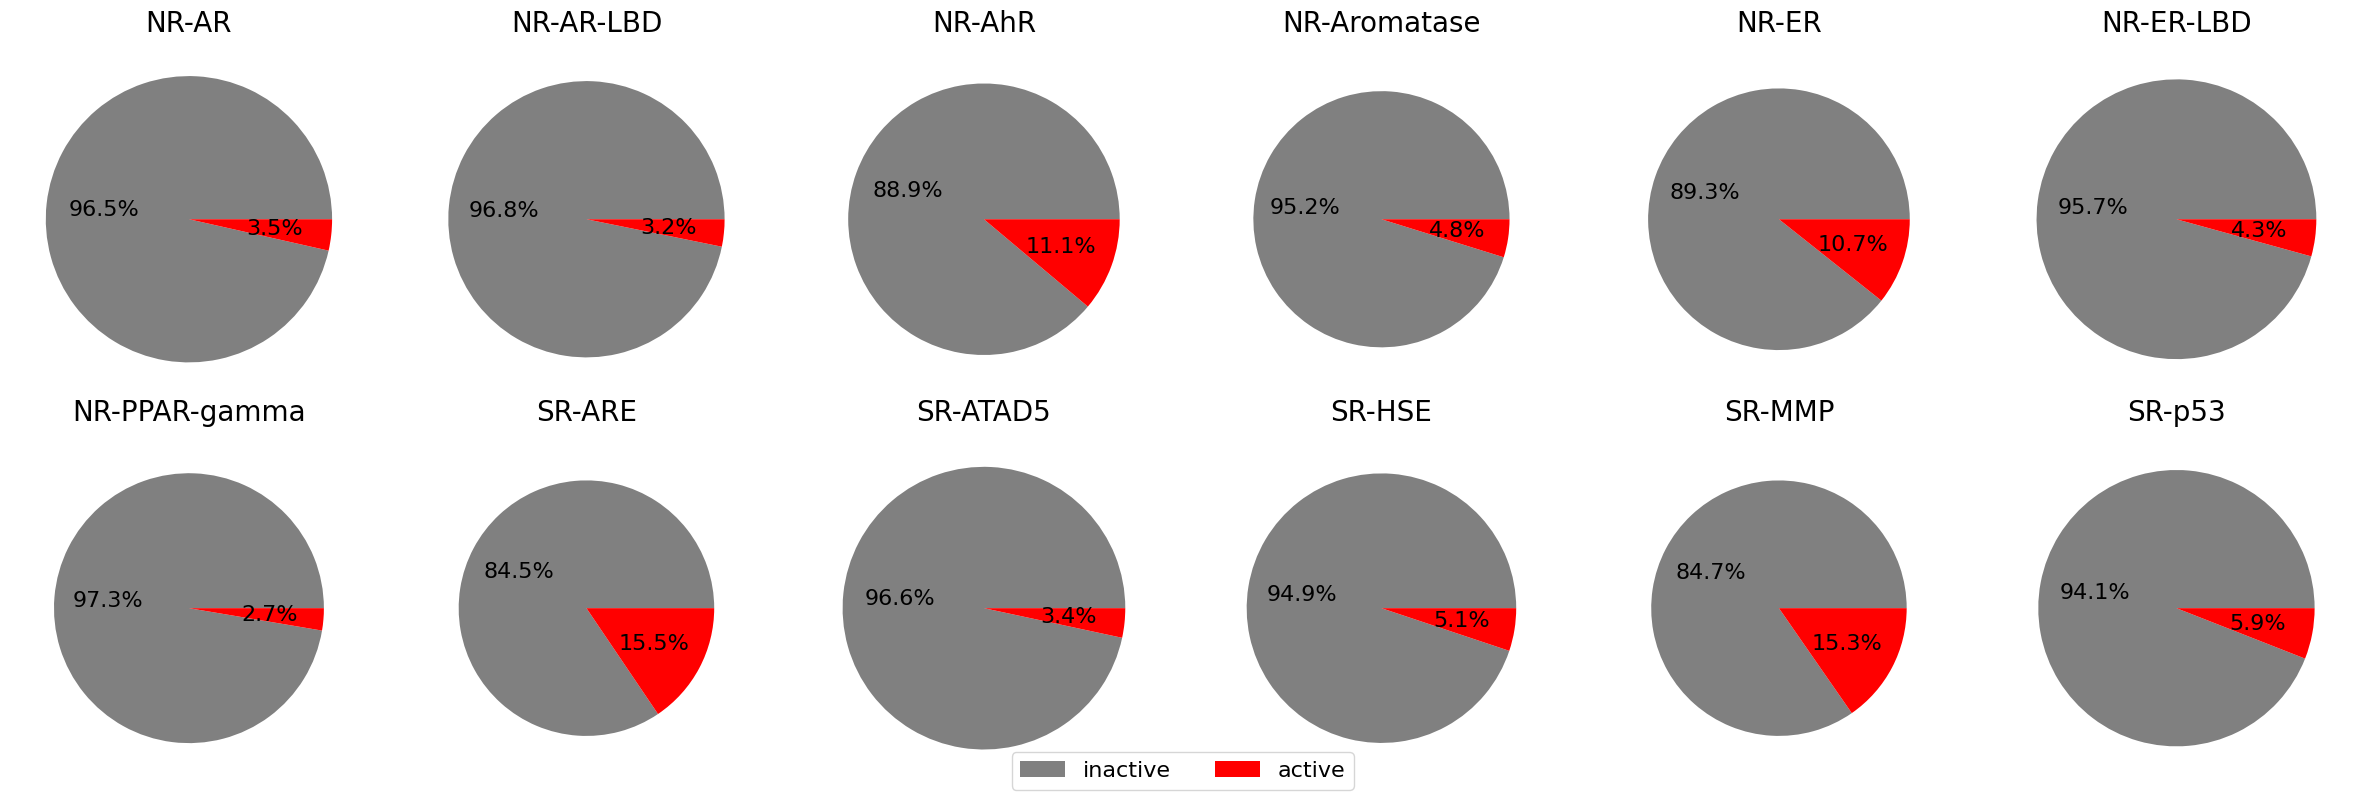

In [ ]:
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Patch

overview_for_plot = overview.iloc[5:, :].sort_index()

# subplot structure
ncols = 6
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()

# radius 정규화용
max_sum = overview_for_plot["count_sum"].max()

for ax, (idx, row) in zip(axes, overview_for_plot.iterrows()):
    values = [row["count_0"], row["count_1"]]

    # count_sum에 비례하도록 반지름 설정
    # 너무 차이가 크면 작은 파이가 너무 안 보이므로 sqrt 추천
    radius = (row["count_sum"] / max_sum) ** 0.5

    ax.pie(
        values,
        colors = ["gray", "red"],
        autopct="%1.1f%%",
        radius=radius,
        textprops={'fontsize': 16}
    )
    ax.set_title(str(idx), fontsize=20)

# legend용 박스 만들기
legend_elements = [
    Patch(facecolor='gray', label='inactive'),
    Patch(facecolor='red', label='active')
]

# figure 전체에 legend 추가
fig.legend(
    handles=legend_elements,
    loc='lower center',   # 오른쪽에 위치
    fontsize=16,
    ncol=2
)

plt.tight_layout()
plt.show()

In [ ]:
df_filtered.shape

(8041, 17)

In [ ]:
# chemical based - NaN data coverage
null_per_row = df_filtered.isna().sum(axis=1)
null_per_row = null_per_row.value_counts().sort_index()
null_per_row

,count
0,2899
1,1607
2,1213
3,695
4,439
5,282
6,184
7,117
8,68
9,53


In [ ]:
for i in range(0,12):
  covered_num = null_per_row.loc[0:i].sum()
  entire_num = df_filtered.shape[0]
  print(f"When we include chemicals with {i} nulls, we can cover {covered_num} out of {entire_num} tested compounds, which is {covered_num/entire_num*100:.1f}% of entire dataset.")


When we include chemicals with 0 nulls, we can cover 2899 out of 8041 tested compounds, which is 36.1% of entire dataset.
When we include chemicals with 1 nulls, we can cover 4506 out of 8041 tested compounds, which is 56.0% of entire dataset.
When we include chemicals with 2 nulls, we can cover 5719 out of 8041 tested compounds, which is 71.1% of entire dataset.
When we include chemicals with 3 nulls, we can cover 6414 out of 8041 tested compounds, which is 79.8% of entire dataset.
When we include chemicals with 4 nulls, we can cover 6853 out of 8041 tested compounds, which is 85.2% of entire dataset.
When we include chemicals with 5 nulls, we can cover 7135 out of 8041 tested compounds, which is 88.7% of entire dataset.
When we include chemicals with 6 nulls, we can cover 7319 out of 8041 tested compounds, which is 91.0% of entire dataset.
When we include chemicals with 7 nulls, we can cover 7436 out of 8041 tested compounds, which is 92.5% of entire dataset.
When we include chemical

# 1-1. Create Morgan fingerprint

In [ ]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

# Morgan generator 생성
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def smiles_to_morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return morgan_gen.GetFingerprintAsNumPy(mol)

def build_morgan_fp_to_df(df, smiles_col="smiles"):
    df = df.copy()

    fps = []
    is_valid_list = []

    for smi in df[smiles_col]:
        fp = smiles_to_morgan_fp(smi)
        fps.append(fp)
        is_valid_list.append(fp is not None)

    df["morgan_fp"] = fps
    df["is_valid"] = is_valid_list

    return df

In [ ]:
df_filtered.head(3)

,idx,canonical_smiles,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD
0,687,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,C17H22BrNO4,384.2649 (303.3529+80.9119),25419,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
1,5652,Br.CC(N)Cc1ccc(O)cc1,C9H14BrNO,232.1176 (80.9119+151.2056),25961,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3557,Br.CCCCCCCCN1C=CN(C)C1,C12H25BrN2,277.2443 (196.3324+80.9119),29288,0.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0


In [ ]:
df_w_fp = build_morgan_fp_to_df(df_filtered, smiles_col="canonical_smiles")
df_w_fp.head(3)

[08:49:56] WARNING: not removing hydrogen atom without neighbors


,idx,canonical_smiles,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD,morgan_fp,is_valid
0,687,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,C17H22BrNO4,384.2649 (303.3529+80.9119),25419,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True
1,5652,Br.CC(N)Cc1ccc(O)cc1,C9H14BrNO,232.1176 (80.9119+151.2056),25961,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True
2,3557,Br.CCCCCCCCN1C=CN(C)C1,C12H25BrN2,277.2443 (196.3324+80.9119),29288,0.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",True


In [ ]:
print(f"Original df (df_filtered): {len(df_filtered)} molecules \nValid SMILES: {df_w_fp['is_valid'].sum()} molecules -> successfully converted to morgan fingerprint in df_w_fp")
print(df_w_fp["morgan_fp"][0].shape)
print(df_w_fp["morgan_fp"][0]) # 0th row fingerprint

Original df (df_filtered): 8041 molecules 
Valid SMILES: 8041 molecules -> successfully converted to morgan fingerprint in df_w_fp
(2048,)
[0 1 0 ... 0 0 0]


# 1-2. calculate RDKit descritors

In [ ]:
df_w_fp.head(3)

,idx,canonical_smiles,Formula,FW,DSSTox_CID,SR-HSE,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD,morgan_fp,is_valid
0,687,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,C17H22BrNO4,384.2649 (303.3529+80.9119),25419,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True
1,5652,Br.CC(N)Cc1ccc(O)cc1,C9H14BrNO,232.1176 (80.9119+151.2056),25961,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True
2,3557,Br.CCCCCCCCN1C=CN(C)C1,C12H25BrN2,277.2443 (196.3324+80.9119),29288,0.0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",True


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen, rdMolDescriptors, rdmolops

def calc_basic_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return {
        "MolWt": Descriptors.MolWt(mol),  # 분자량
        "MolLogP": Crippen.MolLogP(mol),  # 지용성
        "TPSA": rdMolDescriptors.CalcTPSA(mol), # 극성 (topological polar surface area)
        "NumHDonors": Lipinski.NumHDonors(mol), # H-bond donor
        "NumHAcceptors": Lipinski.NumHAcceptors(mol), # H-bond acceptor
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol), # 구조 유연성
        "RingCount": Lipinski.RingCount(mol), # ring 있는지
        "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol), #aromatic ring 있는지
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol), # sp3 hybridized carbon 비율 1에 가까울수록 saturated (chain-like): 3D 구조 높음
        "HeavyAtomCount": Lipinski.HeavyAtomCount(mol), # 무거운 원자 수                      0에 가까울수록 aromatic (sp2구조): planar - stacking/aromatic interactions
        "FormalCharge": rdmolops.GetFormalCharge(mol)
    }

In [ ]:
# apply the function to calculate basic descriptors
desc_df = df_w_fp["canonical_smiles"].apply(calc_basic_descriptors).apply(pd.Series)  # Series: None vs. DataFrame (pd): NaN으로 통일
# concatenate desc_df into the original df                                          # -> apply(pd.Series) 하면 df화 되면서 invalid 값은 NaN이 생김
df_w_fp_desc = pd.concat([df_w_fp, desc_df], axis=1)

[08:50:00] WARNING: not removing hydrogen atom without neighbors


In [ ]:
# create valid column for descriptors
desc_cols = [
    "MolWt", "MolLogP", "TPSA", "NumHDonors", "NumHAcceptors",
    "NumRotatableBonds", "RingCount", "NumAromaticRings",
    "FractionCSP3", "HeavyAtomCount", "FormalCharge"
]

df_w_fp_desc["desc_valid"] = df_w_fp_desc[desc_cols].notna().all(axis=1) # 이 row에서 모든 값이 NaN이 아니면 True
print(df_w_fp_desc.head(3))
print(f"Among {len(df_w_fp_desc)} molecules, we got all valid descriptors from {df_w_fp_desc['desc_valid'].sum()} molecules.")

    idx                         canonical_smiles      Formula  \
0   687  Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1  C17H22BrNO4   
1  5652                     Br.CC(N)Cc1ccc(O)cc1    C9H14BrNO   
2  3557                   Br.CCCCCCCCN1C=CN(C)C1   C12H25BrN2   

                            FW DSSTox_CID  SR-HSE  NR-AR  SR-ARE  \
0  384.2649 (303.3529+80.9119)      25419     0.0    0.0     0.0   
1  232.1176 (80.9119+151.2056)      25961     NaN    0.0     NaN   
2  277.2443 (196.3324+80.9119)      29288     0.0    0.0     0.0   

   NR-Aromatase  NR-ER-LBD  ...   TPSA  NumHDonors  NumHAcceptors  \
0           0.0        0.0  ...  92.95         5.0            5.0   
1           0.0        0.0  ...  46.25         2.0            2.0   
2           NaN        0.0  ...   6.48         0.0            2.0   

   NumRotatableBonds  RingCount  NumAromaticRings  FractionCSP3  \
0                6.0        2.0               2.0      0.294118   
1                2.0        1.0               1.0      

In [ ]:
# create df only using molecules with valid Morgan FP & descriptors (valid_df)
valid_df = df_w_fp_desc[df_w_fp_desc["is_valid"] & df_w_fp_desc["desc_valid"]].copy()

# Create DataFrame with both Morgan FP & descriptors with proper column names
# FP만 있으면 array로도 충분 (np array: 빠름, 메모리 효율, 코드 간단 but 컬럼 이름 없음)
# descriptor도 추가되면 pandas DataFrame 필요 (pd DF: 컬럼 이름있음, feature importance 바로 이해가능 but 약간 느림, 코드 길어짐)
fp_array = np.stack(valid_df["morgan_fp"].values)
fp_df = pd.DataFrame(fp_array, columns=[f"fp_{i}" for i in range(fp_array.shape[1])])

desc_df = valid_df[desc_cols]

X_df = pd.concat([fp_df, desc_df], axis=1)

print(X_df.head(5))
print(X_df.shape) # Morgan FP의 각 bit + descriptor 각각이 전부 하나의 column이 됨 = 2048 bit + 11 descriptors

   fp_0  fp_1  fp_2  fp_3  fp_4  fp_5  fp_6  fp_7  fp_8  fp_9  ...  MolLogP  \
0     0     1     0     0     0     0     0     0     0     0  ...   2.6355   
1     0     1     0     0     0     0     0     0     0     0  ...   1.8598   
2     0     0     0     0     0     0     0     0     0     0  ...   3.6009   
3     0     0     0     0     0     0     0     0     0     0  ...   2.0405   
4     0     0     0     0     0     0     0     0     0     0  ...   1.6504   

    TPSA  NumHDonors  NumHAcceptors  NumRotatableBonds  RingCount  \
0  92.95         5.0            5.0                6.0        2.0   
1  46.25         2.0            2.0                2.0        1.0   
2   6.48         0.0            2.0                7.0        1.0   
3   6.48         0.0            2.0                3.0        1.0   
4   6.48         0.0            2.0                2.0        1.0   

   NumAromaticRings  FractionCSP3  HeavyAtomCount  FormalCharge  
0               2.0      0.294118           

# Phase A. Morgan fingerprint만으로 baseline 정리
- 먼저 Morgan만 가지고 아래를 비교합니다.
- 여기서는 과한 tuning 없이 기본값 또는 약간 손본 strong default 정도로만 갑니다.
- 이 단계 목표는:
1. “모델 순위가 대충 어떻게 되는지”
2. “random vs scaffold gap이 얼마나 큰지”
3. “어떤 모델이 scaffold에서 버티는지”

# A-1. random split baseline
- Logistic Regression
- Random Forest
- LightGBM

## 0. Define function

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

def run_multitarget_random_split(valid_df, X_all, target_cols, base_model):
    """
    Parameters
    ----------
    valid_df : pd.DataFrame
    X_all : np.ndarray or scipy sparse matrix
        valid_df와 row 순서가 정확히 맞아야 함
    target_cols : list[str]
    base_model : input model (e.g., logistic regression, Random forest, LightGBM)

    Returns
    -------
    results_df : pd.DataFrame
    models : dict
        target별 학습된 모델
    """
    # 1. feature / label
    results = []
    models = {}

    for target in target_cols:
        mask = valid_df[target].notna() # 값있으면 T, 없으면 F
        X_task = X_all[mask.values] # mask가 True인 row만 X에서 선택 (.values 없어도 가능 - but pandas는 index 기반 / numpy는 위치 기반이라서 .values로 index 제거해주고 온전히 순서 기반으로 해주는것)
        y_task = valid_df.loc[mask, target].astype(int).values  # .loc[row, column] -> mask가 True인애만 target column에서 가져와라.

        if len(np.unique(y_task)) < 2: # binary classification 이므로 0, 1 -> 2개 있어야
            print(f"SKIP: {target} (only one class)")
            continue  # 지금 반복 스킵 -> 다음 for 반복으로 이동 (다음 target으로) cf. break = 전체 반복 종료

        # 2. split
        X_train, X_test, y_train, y_test = train_test_split(
            X_task, y_task,
            test_size=0.2,
            random_state=42,
            stratify=y_task # y_task class (0, 1) 비율 기준으로 train/test split
        )

        model = clone(base_model)
        model.fit(X_train, y_train)


        # 3. evaluate
        y_prob = model.predict_proba(X_test)[:, 1]  # [P(class=0), P(class=1)] 형태라서 [:,1]은 모든 row에서 두번째값만 선택해오는것 (1일 확률, 즉 active일 확률)

        results.append({
            "target": target,
            "n_samples": len(y_task),
            "positive_ratio": y_task.mean(),
            "roc_auc": roc_auc_score(y_test, y_prob),
            "pr_auc": average_precision_score(y_test, y_prob)
        })

        models[target] = model  # 이렇게 target 마다 구분하지 않으면, 같은 model 객체를 계속 재사용하는 구조라서 매 loop마다 다시 fit되고
                                #최종적으로는 마지막 target에 fit된 모델 상태만 남는다
                                # 그래서 이렇게 쌓아줘야 나중에 target 별로 model 관련 값을 꺼내 쓸수있음 (e.g. feature importance)
    return pd.DataFrame(results), models

## 1. Baseline model with Random Split - (1) Logistic Regression

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy() # = valid_df = df_w_fp[df_w_fp["is_valid"]==True].copy()
X_all = np.stack(valid_df["morgan_fp"].values)  #.values: series를 list로꺼냄; np.stack: 행렬로 변환 - 각 value에 []처리 (1d -> 2d)
target_cols = endpoint_column
lr_model = LogisticRegression(max_iter=2000,
                              class_weight="balanced",  # 클래스 불균형을 자동으로 보정해주는 옵션
                              solver="liblinear", # Logistic Regression을 어떤 알고리즘으로 풀지 선택 - liblinear: binary에 강함 vs. lbfgs: multi-class vs. saga: 대용량+ L1
                              random_state=42
        )

In [ ]:
# Run model
lr_results_df, lr_model_output = run_multitarget_random_split(valid_df, X_all, target_cols, lr_model)
print(lr_results_df)
print("Mean ROC-AUC:", lr_results_df["roc_auc"].mean())
print("Mean PR-AUC :", lr_results_df["pr_auc"].mean())

           target  n_samples  positive_ratio   roc_auc    pr_auc
0          SR-HSE       6573        0.051270  0.758037  0.280031
1           NR-AR       7417        0.035189  0.797661  0.571712
2          SR-ARE       5908        0.155383  0.783714  0.462124
3    NR-Aromatase       5938        0.047996  0.830223  0.443801
4       NR-ER-LBD       7082        0.042785  0.795747  0.455958
5          NR-AhR       6670        0.111244  0.870733  0.560448
6          SR-MMP       5905        0.153429  0.855483  0.624525
7           NR-ER       6195        0.106860  0.714102  0.391667
8   NR-PPAR-gamma       6591        0.026551  0.847040  0.364403
9          SR-p53       6909        0.059488  0.762702  0.355237
10       SR-ATAD5       7230        0.033610  0.757980  0.243567
11      NR-AR-LBD       6907        0.031852  0.791531  0.510139
Mean ROC-AUC: 0.7970794357432376
Mean PR-AUC : 0.43863428434213864


In [ ]:
lr_model_output

{'SR-HSE': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
                    solver='liblinear'),
 'NR-AR': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
                    solver='liblinear'),
 'SR-ARE': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
                    solver='liblinear'),
 'NR-Aromatase': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
                    solver='liblinear'),
 'NR-ER-LBD': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
                    solver='liblinear'),
 'NR-AhR': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
                    solver='liblinear'),
 'SR-MMP': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
                    solver='liblinear'),
 'NR-ER': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
          

In [ ]:
# Performance 측정치 공부
# Precision, Recall, F1 등은 결정된 threshold에서의 성능 - “최종 예측 결과 (0 or 1)” 기준 평가, threshold(보통 0.5)에 강하게 의존
# AUC는 모델 자체의 능력 (threshold 없이 평가) - 확률 자체로 평가
#- baseline 비교 단계에서는 AUC가 더 표준, 특히 Tox21은 PR-AUC 중요 (imbalanced data)

# ROC-AUC (Receiver Operating Characteristic - Area Under Curve): 모델이 positive를 negative보다 얼마나 잘 구분하냐 (positive를 더 잘 맞출 확률)
#                                                                  => "확률을 얼마나 잘 순서대로 정렬했냐"
#                                                                   (0.7-0.8 이상이면 좋음)
# PR-AUC: Precision-Recall AUC: positive를 얼마나 잘 잡고, 틀린 것 얼마나 적은지 =>"positive를 얼마나 정확하게 많이 잡냐"
#                               **positive 중심, imbalance 영향 큼 -> Tox21 데이터에서 중요
#                                (데이터에 따라 다름, baseline 대비 얼마나 개선됐는지 중요)

## 1. Baseline model with Random Split - (2) Random Forest - default / strong default

In [ ]:
### Random Forest model v1
from sklearn.ensemble import RandomForestClassifier

# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy()
X_all = np.stack(valid_df["morgan_fp"].values)
target_cols = endpoint_column
rf_model_v1 = RandomForestClassifier(n_estimators=300,        # 트리 개수
                               max_depth=None,          # 트리 최대 깊이 제한 없음
                               class_weight="balanced", # 클래스 불균형 보정
                               random_state=42,
                               n_jobs=-1                # 가능한 CPU 코어 다 사용
        )



In [ ]:
# Run model
rf_v1_results_df, rf_model_v1_output = run_multitarget_random_split(valid_df, X_all, target_cols, rf_model_v1)
print(rf_v1_results_df)
print("Mean ROC-AUC:", rf_v1_results_df["roc_auc"].mean())
print("Mean PR-AUC:", rf_v1_results_df["pr_auc"].mean())

           target  n_samples  positive_ratio   roc_auc    pr_auc
0          SR-HSE       6573        0.051270  0.798639  0.315272
1           NR-AR       7417        0.035189  0.801414  0.597824
2          SR-ARE       5908        0.155383  0.832358  0.510862
3    NR-Aromatase       5938        0.047996  0.814828  0.407187
4       NR-ER-LBD       7082        0.042785  0.877642  0.551134
5          NR-AhR       6670        0.111244  0.906462  0.610082
6          SR-MMP       5905        0.153429  0.874633  0.656206
7           NR-ER       6195        0.106860  0.754106  0.441580
8   NR-PPAR-gamma       6591        0.026551  0.868102  0.409816
9          SR-p53       6909        0.059488  0.857134  0.502754
10       SR-ATAD5       7230        0.033610  0.764057  0.288703
11      NR-AR-LBD       6907        0.031852  0.820738  0.548520
Mean ROC-AUC: 0.8308426966617417
Mean PR-AUC: 0.48666159190892905


In [ ]:
### Random Forest model v2 - with strong default (semi-standard values from community and experience, known as working well)
# 현실적으로는 약간은 튜닝한 수준으로 baseline 씀 (아무생각없이 default모델 쓰기보다, 최소한의 상식적인 설정 적용한 모델을 baseline으로 씀)

# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy()
X_all = np.stack(valid_df["morgan_fp"].values)
target_cols = endpoint_column
rf_model_v2 = RandomForestClassifier(n_estimators=500,        # 트리 개수
                                  max_depth=20,
                                  min_samples_leaf=2,
                                  max_features="sqrt",
                                  class_weight="balanced", # 클래스 불균형 보정
                                  random_state=42,
                                  n_jobs=-1                # 가능한 CPU 코어 다 사용
        )

In [ ]:
# Run model
rf_v2_results_df, rf_model_v2_output = run_multitarget_random_split(valid_df, X_all, target_cols, rf_model_v2)
print(rf_v2_results_df)
print("Mean ROC-AUC:", rf_v2_results_df["roc_auc"].mean())
print("Mean PR-AUC:", rf_v2_results_df["pr_auc"].mean())

           target  n_samples  positive_ratio   roc_auc    pr_auc
0          SR-HSE       6573        0.051270  0.750634  0.319465
1           NR-AR       7417        0.035189  0.813265  0.599631
2          SR-ARE       5908        0.155383  0.793266  0.485167
3    NR-Aromatase       5938        0.047996  0.837421  0.395058
4       NR-ER-LBD       7082        0.042785  0.830408  0.512576
5          NR-AhR       6670        0.111244  0.890217  0.580091
6          SR-MMP       5905        0.153429  0.856876  0.638856
7           NR-ER       6195        0.106860  0.757449  0.443534
8   NR-PPAR-gamma       6591        0.026551  0.891989  0.399762
9          SR-p53       6909        0.059488  0.816407  0.423101
10       SR-ATAD5       7230        0.033610  0.793771  0.264027
11      NR-AR-LBD       6907        0.031852  0.822819  0.550401
Mean ROC-AUC: 0.8212101415801242
Mean PR-AUC: 0.46763911080996357


In [ ]:
# 추가로 실무적으로는 Morgan fingerprint + Random Forest 할 때 아래 파라미터도 자주 조절:

# 1. n_estimators: 200~1000 # 트리 몇개 만들지
# 2. max_depth: 10~30 너무 깊으면 과적합 가능  # 트리가 얼마나 깊게 분기할 수 있는지 (깊으면 복잡한 패턴 학습, but 과적합 위험)
# 3. min_samples_leaf: 1, 2, 5 정도 비교 # 하나의 leaf (노드)에 최소 몇개 데이터 있어야 하는지 - e.g. leaf에 데이터 1개면 ovefitting 위험 큼 vs. 5개면 패턴 일반화됨
# 4. max_features: "sqrt" 자주 씀  # 트리가 분기할때 전체 feature 중 몇개만 랜덤으로 골라서 사용 (모든 feature 다보면 트리들이 비슷. 랜덤화 높이기)
                            # sqrt: feature수가 100개면 10개만 사용; log2: 더 적게 사용; None: 모든 feature 사용 (덜 랜덤)

In [ ]:
# “튜닝으로 드라마틱하게 좋아지는 경우는 생각보다 드물다”
# 대부분은 + 0.02 정도면 잘했다는 느낌
# 진짜 성능은 데이터가 결정함
# feature engineering >>>> model tuning

# 튜닝했는데 평균 성능 떨어지는 건 흔함 -> 특히 multitarget에서는 더 자주 발생
# 튜닝 = 특정패턴에 맞춤이라서, 어떤 데이터 구조에는 좋고 어떤 데이터에는 안맞을수 있음.
# 특히 multi task이므로 하나의 모델 세팅으로 여러 task를 동시에 만족시키위한 상황
# 튜닝이 일부 task에는 도움이 됐지만, 전체적으로는 오히려 over-regularization 됨
# “global hyperparameter는 모든 task에 최적이 아니다”

## 1. Baseline model with Random Split - (3) LightGBM - default / strong default

In [ ]:
# Random Forest vs. LightGBM
# 둘다 트리 기반 모델
# Random Forest는 여러 트리를 독립적으로 만든다 (각각 따로 학습, 마지막에 평균) - 병렬 가능, 안정적, 과적합 덜함
# - baseline, 해석 쉬움, 데이터 작을때
# LightGBM은 트리를 순차적으로 많이 만들어서 점점 성능을 개선하는 모델 (이전 모델이 틀린걸 다음이 보완) - 성능 높음, 과적합 위험있음
# - 성능 중요할때, tabular 데이터, kaggle/ 실무 대부분
#
# Random Forest는 “평균”, LightGBM은 “오답을 집중적으로 고침”
# Morgan Fingerprint에서 왜 boosting이 잘 먹히냐?
# Morgan FP: 0/1 벡터 (sparse)/ feature 수 많음 (1024, 2048 등)/ 중요한 feature는 일부만 의미 있음
# -> 많은 feature가 noise거나 weak signal => LightGBM은 중요한 feature를 점점 강조, weak signal을 누적, sparse 데이터 처리 잘

In [ ]:
# 왜  logistic regression 이랑 random forest는 morgan FP 만 하고 XGBoost 는 RDkit 도 포함하는거야?
# LR / RF는 fingerprint만으로도 충분히 baseline이 잘 나오고
# XGBoost는 descriptor까지 넣으면 더 잘 활용하는 경우가 많기 때문입니다.
# 1. Logistic regression: 모델 단순. 선형모델이라 복잡한 feature 조합 잘 못잡음
# 2. Random Forest: LR보다는 강력, 비선형 가능, feature interaction 일부  가능 but 여전히 high dimensional sparse input (2048bit)에서 잘 작동함
# 3. XGBoost는 tabular 데이터 최강, 다양한 feature 조합 잘 잡음, heterogenous feature를 잘 섞음
# LF이나 RF에도 descriptor 넣어도 되지만 성능 개선이 크지 않음
# LightGBM (빠름, 성능 좋음, 대용량 데이터, 과적합될수도) vs. XGBoost (안정적, 전통적) vs. CatBoost (안정적, one hot 자동처리) - gradient boosting 기반 트리모델

In [ ]:
### LightGBM model v1
from lightgbm import LGBMClassifier

# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy() # = valid_df = df_w_fp[df_w_fp["is_valid"]==True].copy()
X_all = np.stack(valid_df["morgan_fp"].values).astype(np.float32) # 추가했음 (X dtype 통일시키기) - int로 해도 상관없지만, lightGBM 기준 내부적으로 결국 float로 변환해서 계산함
target_cols = endpoint_column                                     # 그리고 메모리 효율 좋음: int = 8 bytes ; float32 = 4 bytes

lg_model_v1 = LGBMClassifier(
        n_estimators=300, # 트리 300개
        learning_rate=0.05, # 너무 공격적이지 않게 (각 트리가 얼마나 조심스럽게 학습할지, 한번에 크게 고칠까 조금씩 고칠까)
                              # ** 낮은 learning rate -> n_estimators (트리개수) 증가해야 (조금씩 수정-> 천천히 학습 -> 많은 트리 필요)
        num_leaves=31,  # LightGBM 핵심: 트리 복잡도
        max_depth=-1,          # 제한 없음 (LightGBM은 leaf-wise라서 depth보다 leaf가 중요 -> 그래서 보통 -1로 설정 or 10-20정도)
        subsample=0.8,         # row sampling (데이터의 일부만 사용해서 트리 학습) -> 과적합 방지 (regularization)
        colsample_bytree=0.8,  # feature sampling (feature 일부만 사용해서 split)-> 과적합 방지 (regularization)
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1  # 로그 출력 안함
        )

In [ ]:
# Run model
lg_v1_results_df, lg_model_v1_output = run_multitarget_random_split(valid_df, X_all, target_cols, lg_model_v1)
print(lg_v1_results_df)
print(f"Mean ROC-AUC:", lg_v1_results_df["roc_auc"].mean())
print(f"Mean PR-AUC:", lg_v1_results_df["pr_auc"].mean())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

           target  n_samples  positive_ratio   roc_auc    pr_auc
0          SR-HSE       6573        0.051270  0.784850  0.296720
1           NR-AR       7417        0.035189  0.821001  0.606123
2          SR-ARE       5908        0.155383  0.805421  0.507260
3    NR-Aromatase       5938        0.047996  0.792312  0.416154
4       NR-ER-LBD       7082        0.042785  0.827748  0.545569
5          NR-AhR       6670        0.111244  0.891567  0.606603
6          SR-MMP       5905        0.153429  0.874229  0.675347
7           NR-ER       6195        0.106860  0.716771  0.441925
8   NR-PPAR-gamma       6591        0.026551  0.859123  0.371619
9          SR-p53       6909        0.059488  0.796576  0.428962
10       SR-ATAD5       7230        0.033610  0.771318  0.326217
11      NR-AR-LBD       6907        0.031852  0.817078  0.505980
Mean ROC-AUC: 0.8131661511915045
Mean PR-AUC: 0.4773733809807735


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
### LightGBM model v1

# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy() # = valid_df = df_w_fp[df_w_fp["is_valid"]==True].copy()
X_all = np.stack(valid_df["morgan_fp"].values).astype(np.float32) # 추가했음 (X dtype 통일시키기) - int로 해도 상관없지만, lightGBM 기준 내부적으로 결국 float로 변환해서 계산함
target_cols = endpoint_column                                     # 그리고 메모리 효율 좋음: int = 8 bytes ; float32 = 4 bytes

lg_model_v2 = LGBMClassifier(
            n_estimators=500, # 트리 500개
            learning_rate=0.03, # 위에보다는 더 천천히 학습
            num_leaves=64,  # 위에보다 더 복잡하게
            min_child_samples=20,
            subsample=0.8,         # row sampling (데이터의 일부만 사용해서 트리 학습) -> 과적합 방지 (regularization)
            colsample_bytree=0.8,  # feature sampling (feature 일부만 사용해서 split)-> 과적합 방지 (regularization)
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbose=-1  # 로그 출력 안함
        )

In [ ]:
# Run model
lg_v2_results_df, lg_model_v2_output = run_multitarget_random_split(valid_df, X_all, target_cols, lg_model_v2)
print(lg_v2_results_df)
print(f"Mean ROC-AUC:", lg_v2_results_df["roc_auc"].mean())
print(f"Mean PR-AUC:", lg_v2_results_df["pr_auc"].mean())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

           target  n_samples  positive_ratio   roc_auc    pr_auc
0          SR-HSE       6573        0.051270  0.787050  0.295597
1           NR-AR       7417        0.035189  0.817241  0.604949
2          SR-ARE       5908        0.155383  0.827650  0.516589
3    NR-Aromatase       5938        0.047996  0.812230  0.434257
4       NR-ER-LBD       7082        0.042785  0.849050  0.567790
5          NR-AhR       6670        0.111244  0.903879  0.637072
6          SR-MMP       5905        0.153429  0.874296  0.669313
7           NR-ER       6195        0.106860  0.725531  0.437989
8   NR-PPAR-gamma       6591        0.026551  0.841144  0.397317
9          SR-p53       6909        0.059488  0.804756  0.463028
10       SR-ATAD5       7230        0.033610  0.785619  0.332824
11      NR-AR-LBD       6907        0.031852  0.823040  0.507836
Mean ROC-AUC: 0.820957018236223
Mean PR-AUC: 0.4887132980166093


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 2. Performance comparison - Random split

In [ ]:
# comparison of performance - default / strong default
dfs = [lr_results_df,rf_v1_results_df, rf_v2_results_df, lg_v1_results_df, lg_v2_results_df]
dfs_selected = []
names = ["lr", "rf_v1", "rf_v2", "lg_v1", "lg_v2"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["roc_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_roc_auc_random_split_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_roc_auc_random_split_df.loc["roc_auc_mean"] = results_roc_auc_random_split_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_roc_auc_random_split_df

# ## cf. target = mean 으로
# mean_row = results_roc_auc_random_split_df.mean(numeric_only = True)
# mean_row["target"] = "roc_auc_mean"
# compare_rf_df_with_mean = pd.concat([results_roc_auc_random_split_df, pd.DataFrame([mean_row])], ignore_index = True) # 기존 index 무시하고 mean row까지 포함한 인덱스 새로 부여하라고.
# compare_rf_df_with_mean

,target,lr,rf_v1,rf_v2,lg_v1,lg_v2
0,SR-HSE,0.758037,0.798639,0.750634,0.784850,0.787050
1,NR-AR,0.797661,0.801414,0.813265,0.821001,0.817241
2,SR-ARE,0.783714,0.832358,0.793266,0.805421,0.827650
3,NR-Aromatase,0.830223,0.814828,0.837421,0.792312,0.812230
4,NR-ER-LBD,0.795747,0.877642,0.830408,0.827748,0.849050
5,NR-AhR,0.870733,0.906462,0.890217,0.891567,0.903879
6,SR-MMP,0.855483,0.874633,0.856876,0.874229,0.874296
7,NR-ER,0.714102,0.754106,0.757449,0.716771,0.725531
8,NR-PPAR-gamma,0.847040,0.868102,0.891989,0.859123,0.841144
9,SR-p53,0.762702,0.857134,0.816407,0.796576,0.804756


In [ ]:
# [Random split] ROC_AUC:: rf_v1 > rf_v2 > lg_v2 > lg_v1 > lr for random split

In [ ]:
# comparison of performance before / after tuning
dfs = [lr_results_df,rf_v1_results_df, rf_v2_results_df, lg_v1_results_df, lg_v2_results_df]
dfs_selected = []
names = ["lr", "rf_v1", "rf_v2", "lg_v1", "lg_v2"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["pr_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_pr_auc_random_split_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_pr_auc_random_split_df.loc["pr_auc_mean"] = results_pr_auc_random_split_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_pr_auc_random_split_df

# ## cf. target = mean 으로
# mean_row = results_pr_auc_random_split_df.mean(numeric_only = True)
# mean_row["target"] = "roc_auc_mean"
# compare_rf_df_with_mean = pd.concat([results_pr_auc_random_split_df, pd.DataFrame([mean_row])], ignore_index = True) # 기존 index 무시하고 mean row까지 포함한 인덱스 새로 부여하라고.
# compare_rf_df_with_mean

,target,lr,rf_v1,rf_v2,lg_v1,lg_v2
0,SR-HSE,0.280031,0.315272,0.319465,0.296720,0.295597
1,NR-AR,0.571712,0.597824,0.599631,0.606123,0.604949
2,SR-ARE,0.462124,0.510862,0.485167,0.507260,0.516589
3,NR-Aromatase,0.443801,0.407187,0.395058,0.416154,0.434257
4,NR-ER-LBD,0.455958,0.551134,0.512576,0.545569,0.567790
5,NR-AhR,0.560448,0.610082,0.580091,0.606603,0.637072
6,SR-MMP,0.624525,0.656206,0.638856,0.675347,0.669313
7,NR-ER,0.391667,0.441580,0.443534,0.441925,0.437989
8,NR-PPAR-gamma,0.364403,0.409816,0.399762,0.371619,0.397317
9,SR-p53,0.355237,0.502754,0.423101,0.428962,0.463028


In [ ]:
# [Random split] PR_AUC:: lg_v2 > rf_v1 > lg_v1 > rf_v2 > lr

In [ ]:
# random forest 성능 > lightGBM 인 상태, why?
# Random Forest가 LightGBM보다 잘 나오는 경우 충분히 있음
# 1. 데이터 크기 영향 (lightGBM은 데이터 많을수록 강해지는 모델, ~6k는 크지 않은 데이터)
# 2. Morgan FP 특성 (RF는 noise에 강한데, lightGBM은 중요한 feature를 계속 파고드는 속성이 있어서 noise까지 집착할 수 있음)
# 3. 튜닝 상태 차이 (lightGBM: 지금은 generic baseline, RF는 이미 꽤 잘 튜닝된 상태임) -- 근데 이건 아닌게, 위에꺼는 RF 튜닝전인데도 성능이 월등하지 않음.
# 4. class imbalance 영향 (일부 target의 positive ratio 매우 낮음 (0.02~0.05) -> RF는 비교적 robust vs. LightGBM은 설정 잘못되면 성능 흔들림)

# A-2. scaffold split baseline
- Logistic Regression
- Random Forest
- LightGBM

## 0. Define functions

In [ ]:
# [Global scaffold split version]
# 1. 동일하게 scaffold split 된 train/test set을 모든 target 에 대해 적용하게 됨
# 2. 한번의 split만으로 평가함 - cf. 내부 CV 방식의 경우 5 split을 반복해서 여러 경우로 평가
# 즉: baseline / 최종 비교는 global scaffold split, 튜닝 / 내부검증 등 유연한 최적화/타겟별 최적화는 target별 split 또는 CV
# (global 하는 이유: target마다 train/test set 이 달라지는 것에 대해 random split은 보통 덜 민감하지만, scaffold는 더 민감해서 공통 split을 따로 두는 경우가 많습니다.)
from sklearn.model_selection import GroupShuffleSplit
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def make_scaffold(smiles):    # side chain 제거하고 core만 남김
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    return scaffold


def run_multitarget_scaffold_split(valid_df, X_all, target_cols, base_model):
    results = []
    prediction_rows = []
    models = {}

    valid_df = valid_df.copy()
    valid_df["scaffold"] = valid_df["canonical_smiles"].apply(make_scaffold)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42) # GSS: “같은 scaffold는 쪼개지지 않고 한 덩어리로 유지된다” (전부 train or 전부 test)-> data leakage 방지
    global_train_idx, global_test_idx = next(                           # scaffold group 단위로 통째로 train/test 배정
        gss.split(valid_df, groups=valid_df["scaffold"])  # train /test로 scaffold 기준으로 나눠서 행위치 기반으로 인덱스를 분리함.
    )

    global_train_index = valid_df.index[global_train_idx] # 행 위치 인덱스 -> 원래 DataFrame의 index 라벨로 바꾸기 (나중에 유용)
    global_test_index = valid_df.index[global_test_idx]

    for target in target_cols:
        mask = valid_df[target].notna()
        task_df = valid_df.loc[mask].copy()
        y_task = task_df[target].astype(int).values

        if len(np.unique(y_task)) < 2:
            print(f"SKIP: {target} (only one class)")
            continue

        task_train_mask = task_df.index.isin(global_train_index)
        task_test_mask = task_df.index.isin(global_test_index)

        if task_train_mask.sum() == 0 or task_test_mask.sum() == 0: # 표본수가 적어서 split 후 mask 적용시 다 filtering 된 경우 방지하려고
            print(f"SKIP: {target} (empty train/test after scaffold split)")
            continue

        X_task = X_all[mask.values]
        X_train = X_task[task_train_mask]
        X_test = X_task[task_test_mask]
        y_train = y_task[task_train_mask]
        y_test = y_task[task_test_mask]

        test_indices = task_df.index[task_test_mask]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"SKIP: {target} (train/test has only one class)")
            continue

        model = clone(base_model)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "target": target,
            "n_samples": len(y_task),
            "train_n": len(y_train),
            "test_n": len(y_test),
            "positive_ratio": y_task.mean(),
            "roc_auc": roc_auc_score(y_test, y_prob),
            "pr_auc": average_precision_score(y_test, y_prob)
        })
        # prediction-level 저장
        pred_df = pd.DataFrame({
            "target": target,
            "row_index": test_indices,
            "y_true": y_test,
            "y_prob": y_prob,
        })

        # 필요하면 해석용 정보 추가
        pred_df["canonical_smiles"] = task_df.loc[test_indices, "canonical_smiles"].values
        pred_df["scaffold"] = task_df.loc[test_indices, "scaffold"].values

        prediction_rows.append(pred_df)

        models[target] = model

    results_df = pd.DataFrame(results)
    predictions_df = pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame() # prediction_rows는 target별로 형성된 df의 리스트임

    return results_df, predictions_df, models

## 1. Baseline model with Scaffold split - (1) Logistic regression

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy() # = valid_df = df_w_fp[df_w_fp["is_valid"]==True].copy()
X_all = np.stack(valid_df["morgan_fp"].values)  #.values: series를 list로꺼냄; np.stack: 행렬로 변환 - 각 value에 []처리 (1d -> 2d)
target_cols = endpoint_column
lr_scaffold_model = LogisticRegression(max_iter=2000,
                              class_weight="balanced",  # 클래스 불균형을 자동으로 보정해주는 옵션
                              solver="liblinear", # Logistic Regression을 어떤 알고리즘으로 풀지 선택 - liblinear: binary에 강함 vs. lbfgs: multi-class vs. saga: 대용량+ L1
                              random_state=42
        )

In [ ]:
# Run model
lr_scaffold_results_df, _, lr_scaffold_model_output = run_multitarget_scaffold_split(valid_df, X_all, target_cols, lr_scaffold_model)
print(lr_scaffold_results_df)
print("Mean ROC-AUC:", lr_scaffold_results_df["roc_auc"].mean())
print("Mean PR-AUC :", lr_scaffold_results_df["pr_auc"].mean())

[10:43:53] WARNING: not removing hydrogen atom without neighbors


           target  n_samples  train_n  test_n  positive_ratio   roc_auc  \
0          SR-HSE       6573     5851     722        0.051270  0.711355   
1           NR-AR       7417     6535     882        0.035189  0.862058   
2          SR-ARE       5908     5273     635        0.155383  0.712886   
3    NR-Aromatase       5938     5287     651        0.047996  0.788240   
4       NR-ER-LBD       7082     6277     805        0.042785  0.881333   
5          NR-AhR       6670     5910     760        0.111244  0.820445   
6          SR-MMP       5905     5259     646        0.153429  0.784027   
7           NR-ER       6195     5511     684        0.106860  0.749461   
8   NR-PPAR-gamma       6591     5853     738        0.026551  0.757827   
9          SR-p53       6909     6142     767        0.059488  0.710980   
10       SR-ATAD5       7230     6399     831        0.033610  0.829369   
11      NR-AR-LBD       6907     6123     784        0.031852  0.937161   

      pr_auc  
0   0.240

## 1. Baseline model with Scaffold split - (2) Random Forest model

In [ ]:
### Random Forest model v1
from sklearn.ensemble import RandomForestClassifier

# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy()
X_all = np.stack(valid_df["morgan_fp"].values)
target_cols = endpoint_column
rf_scaffold_model_v1 = RandomForestClassifier(n_estimators=300,        # 트리 개수
                               max_depth=None,          # 트리 최대 깊이 제한 없음
                               class_weight="balanced", # 클래스 불균형 보정
                               random_state=42,
                               n_jobs=-1                # 가능한 CPU 코어 다 사용
        )



In [ ]:
# Run model
rf_scaffold_v1_results_df, _, rf_scaffold_model_v1_output = run_multitarget_scaffold_split(valid_df, X_all, target_cols, rf_scaffold_model_v1)
print(rf_scaffold_v1_results_df)
print("Mean ROC-AUC:", rf_scaffold_v1_results_df["roc_auc"].mean())
print("Mean PR-AUC:", rf_scaffold_v1_results_df["pr_auc"].mean())

[10:44:01] WARNING: not removing hydrogen atom without neighbors


           target  n_samples  train_n  test_n  positive_ratio   roc_auc  \
0          SR-HSE       6573     5851     722        0.051270  0.766647   
1           NR-AR       7417     6535     882        0.035189  0.890755   
2          SR-ARE       5908     5273     635        0.155383  0.798959   
3    NR-Aromatase       5938     5287     651        0.047996  0.763148   
4       NR-ER-LBD       7082     6277     805        0.042785  0.838176   
5          NR-AhR       6670     5910     760        0.111244  0.898970   
6          SR-MMP       5905     5259     646        0.153429  0.831493   
7           NR-ER       6195     5511     684        0.106860  0.753009   
8   NR-PPAR-gamma       6591     5853     738        0.026551  0.778012   
9          SR-p53       6909     6142     767        0.059488  0.824885   
10       SR-ATAD5       7230     6399     831        0.033610  0.930693   
11      NR-AR-LBD       6907     6123     784        0.031852  0.956768   

      pr_auc  
0   0.415

In [ ]:
### Random Forest model v2

## 모델 파라미터들 조금 튜닝한 버전 (튜닝: 커뮤니티 + 경험에서 나온 준표준값 - 대체로 잘 먹힌다고 알려진 값임, strong default)
# 현실적으로는 약간은 튜닝한 수준으로 baseline 씀 (아무생각없이 default모델 쓰기보다, 최소한의 상식적인 설정 적용한 모델을 baseline으로 씀)

# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy()
X_all = np.stack(valid_df["morgan_fp"].values)
target_cols = endpoint_column
rf_scaffold_model_v2 = RandomForestClassifier(n_estimators=500,        # 트리 개수
                                  max_depth=20,
                                  min_samples_leaf=2,
                                  max_features="sqrt",
                                  class_weight="balanced", # 클래스 불균형 보정
                                  random_state=42,
                                  n_jobs=-1                # 가능한 CPU 코어 다 사용
        )

In [ ]:
# Run model
rf_scaffold_v2_results_df, _, rf_scaffold_model_v2_output = run_multitarget_scaffold_split(valid_df, X_all, target_cols, rf_scaffold_model_v2)
print(rf_scaffold_v2_results_df)
print("Mean ROC-AUC:", rf_scaffold_v2_results_df["roc_auc"].mean())
print("Mean PR-AUC:", rf_scaffold_v2_results_df["pr_auc"].mean())

[10:46:29] WARNING: not removing hydrogen atom without neighbors


           target  n_samples  train_n  test_n  positive_ratio   roc_auc  \
0          SR-HSE       6573     5851     722        0.051270  0.711106   
1           NR-AR       7417     6535     882        0.035189  0.891971   
2          SR-ARE       5908     5273     635        0.155383  0.762638   
3    NR-Aromatase       5938     5287     651        0.047996  0.741229   
4       NR-ER-LBD       7082     6277     805        0.042785  0.883673   
5          NR-AhR       6670     5910     760        0.111244  0.912608   
6          SR-MMP       5905     5259     646        0.153429  0.844178   
7           NR-ER       6195     5511     684        0.106860  0.796142   
8   NR-PPAR-gamma       6591     5853     738        0.026551  0.793249   
9          SR-p53       6909     6142     767        0.059488  0.842560   
10       SR-ATAD5       7230     6399     831        0.033610  0.860471   
11      NR-AR-LBD       6907     6123     784        0.031852  0.958445   

      pr_auc  
0   0.379

## 1. Baseline model with Scaffold split - (3) LightGBM

In [ ]:
### LightGBM model v1
from lightgbm import LGBMClassifier

# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy() # = valid_df = df_w_fp[df_w_fp["is_valid"]==True].copy()
X_all = np.stack(valid_df["morgan_fp"].values).astype(np.float32) # 추가했음 (X dtype 통일시키기) - int로 해도 상관없지만, lightGBM 기준 내부적으로 결국 float로 변환해서 계산함
target_cols = endpoint_column                                     # 그리고 메모리 효율 좋음: int = 8 bytes ; float32 = 4 bytes

lg_scaffold_model_v1 = LGBMClassifier(
                        n_estimators=300, # 트리 300개
                        learning_rate=0.05, # 너무 공격적이지 않게 (각 트리가 얼마나 조심스럽게 학습할지, 한번에 크게 고칠까 조금씩 고칠까)
                                              # ** 낮은 learning rate -> n_estimators (트리개수) 증가해야 (조금씩 수정-> 천천히 학습 -> 많은 트리 필요)
                        num_leaves=31,  # LightGBM 핵심: 트리 복잡도
                        max_depth=-1,          # 제한 없음 (LightGBM은 leaf-wise라서 depth보다 leaf가 중요 -> 그래서 보통 -1로 설정 or 10-20정도)
                        subsample=0.8,         # row sampling (데이터의 일부만 사용해서 트리 학습) -> 과적합 방지 (regularization)
                        colsample_bytree=0.8,  # feature sampling (feature 일부만 사용해서 split)-> 과적합 방지 (regularization)
                        class_weight="balanced",
                        random_state=42,
                        n_jobs=-1,
                        verbose=-1  # 로그 출력 안함
                        )

In [ ]:
# Run model
lg_scaffold_v1_results_df, _, lg_scaffold_model_v1_output = run_multitarget_scaffold_split(valid_df, X_all, target_cols, lg_scaffold_model_v1)
print(lg_scaffold_v1_results_df)
print(f"Mean ROC-AUC:", lg_scaffold_v1_results_df["roc_auc"].mean())
print(f"Mean PR-AUC:", lg_scaffold_v1_results_df["pr_auc"].mean())

[10:50:01] WARNING: not removing hydrogen atom without neighbors
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

           target  n_samples  train_n  test_n  positive_ratio   roc_auc  \
0          SR-HSE       6573     5851     722        0.051270  0.723775   
1           NR-AR       7417     6535     882        0.035189  0.870469   
2          SR-ARE       5908     5273     635        0.155383  0.787385   
3    NR-Aromatase       5938     5287     651        0.047996  0.707032   
4       NR-ER-LBD       7082     6277     805        0.042785  0.845731   
5          NR-AhR       6670     5910     760        0.111244  0.874950   
6          SR-MMP       5905     5259     646        0.153429  0.824945   
7           NR-ER       6195     5511     684        0.106860  0.746060   
8   NR-PPAR-gamma       6591     5853     738        0.026551  0.774913   
9          SR-p53       6909     6142     767        0.059488  0.804032   
10       SR-ATAD5       7230     6399     831        0.033610  0.805639   
11      NR-AR-LBD       6907     6123     784        0.031852  0.939429   

      pr_auc  
0   0.348

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
### LightGBM model v2

# Define data and model
valid_df = df_w_fp[df_w_fp["is_valid"]].copy() # = valid_df = df_w_fp[df_w_fp["is_valid"]==True].copy()
X_all = np.stack(valid_df["morgan_fp"].values).astype(np.float32) # 추가했음 (X dtype 통일시키기) - int로 해도 상관없지만, lightGBM 기준 내부적으로 결국 float로 변환해서 계산함
target_cols = endpoint_column                                     # 그리고 메모리 효율 좋음: int = 8 bytes ; float32 = 4 bytes

lg_scaffold_model_v2 = LGBMClassifier(
                        n_estimators=500, # 트리 500개
                        learning_rate=0.03, # 위에보다는 더 천천히 학습
                        num_leaves=64,  # 위에보다 더 복잡하게
                        min_child_samples=20,
                        subsample=0.8,         # row sampling (데이터의 일부만 사용해서 트리 학습) -> 과적합 방지 (regularization)
                        colsample_bytree=0.8,  # feature sampling (feature 일부만 사용해서 split)-> 과적합 방지 (regularization)
                        class_weight="balanced",
                        random_state=42,
                        n_jobs=-1,
                        verbose=-1  # 로그 출력 안함
                    )

In [ ]:
# Run model
lg_scaffold_v2_results_df, _, lg_scaffold_model_v2_output = run_multitarget_scaffold_split(valid_df, X_all, target_cols, lg_scaffold_model_v2)
print(lg_scaffold_v2_results_df)
print(f"Mean ROC-AUC:", lg_scaffold_v2_results_df["roc_auc"].mean())
print(f"Mean PR-AUC:", lg_scaffold_v2_results_df["pr_auc"].mean())

[10:50:17] WARNING: not removing hydrogen atom without neighbors
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

           target  n_samples  train_n  test_n  positive_ratio   roc_auc  \
0          SR-HSE       6573     5851     722        0.051270  0.717232   
1           NR-AR       7417     6535     882        0.035189  0.872716   
2          SR-ARE       5908     5273     635        0.155383  0.791101   
3    NR-Aromatase       5938     5287     651        0.047996  0.716001   
4       NR-ER-LBD       7082     6277     805        0.042785  0.831281   
5          NR-AhR       6670     5910     760        0.111244  0.874031   
6          SR-MMP       5905     5259     646        0.153429  0.805452   
7           NR-ER       6195     5511     684        0.106860  0.740715   
8   NR-PPAR-gamma       6591     5853     738        0.026551  0.784237   
9          SR-p53       6909     6142     767        0.059488  0.801052   
10       SR-ATAD5       7230     6399     831        0.033610  0.845512   
11      NR-AR-LBD       6907     6123     784        0.031852  0.944810   

      pr_auc  
0   0.308

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# 지금 코드처럼 “scaffold split을 먼저 하고 → 각 target에 적용”하는 방식이 더 표준적
# (1) 전체 데이터 기준으로 scaffold split -> (2) 그 split을 모든 target에 공통 적용
# 만약 target먼저 선정한 뒤 scaffold 나누면 target 마다 test set이 달라짐 , 실험 reproducibility 떨어짐, 우연히 "easy split" 생길 수 있음
# 내가 걱정한 부분: "표본 수 적으면 0.2 split이 제대로 안 될 수 있지 않나?" => 실제로 자주 발생, 그래서 위의 방어로직 있는거임 (np.unique...)
# => 그래서 GroupKFold / StratifiedGroupKFold 활용할 수 있음 (여러번 나눠서 평균 내는 방식)
# GroupKfold: scaffold 기준 유지, 각 fold가 test 역할을 번갈아 수행
# StratifiedGroupKFold: scaffold 유지 & label 비율도 유지 (더 고급) - class imbalance일때 중요
## cf. StratifiedKFold: imbalance만 있음 (group 없음) vs GroupKFold: group만 있음 (imbalance 없음) vs. StratifiedGroupKfold: 둘다있음

## 2. Performance comparison - (1) scaffold split

In [ ]:
# ROC_AUC
dfs = [lr_scaffold_results_df, rf_scaffold_v1_results_df, rf_scaffold_v2_results_df, lg_scaffold_v1_results_df, lg_scaffold_v2_results_df]
dfs_selected = []
names = ["lr_scaf", "rf_v1_scaf", "rf_v2_scaf", "lg_v1_scaf", "lg_v2_scaf"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["roc_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_roc_auc_random_split_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_roc_auc_random_split_df.loc["roc_auc_mean"] = results_roc_auc_random_split_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_roc_auc_random_split_df

# ## cf. target = mean 으로
# mean_row = results_roc_auc_random_split_df.mean(numeric_only = True)
# mean_row["target"] = "roc_auc_mean"
# compare_rf_df_with_mean = pd.concat([results_roc_auc_random_split_df, pd.DataFrame([mean_row])], ignore_index = True) # 기존 index 무시하고 mean row까지 포함한 인덱스 새로 부여하라고.
# compare_rf_df_with_mean

,target,lr_scaf,rf_v1_scaf,rf_v2_scaf,lg_v1_scaf,lg_v2_scaf
0,SR-HSE,0.711355,0.766647,0.711106,0.723775,0.717232
1,NR-AR,0.862058,0.890755,0.891971,0.870469,0.872716
2,SR-ARE,0.712886,0.798959,0.762638,0.787385,0.791101
3,NR-Aromatase,0.788240,0.763148,0.741229,0.707032,0.716001
4,NR-ER-LBD,0.881333,0.838176,0.883673,0.845731,0.831281
5,NR-AhR,0.820445,0.898970,0.912608,0.874950,0.874031
6,SR-MMP,0.784027,0.831493,0.844178,0.824945,0.805452
7,NR-ER,0.749461,0.753009,0.796142,0.746060,0.740715
8,NR-PPAR-gamma,0.757827,0.778012,0.793249,0.774913,0.784237
9,SR-p53,0.710980,0.824885,0.842560,0.804032,0.801052


In [ ]:
# [scaffold split] ROC_AUC:: rf_v1 > rf_v2 > lg_v2 > lg_v1 > lr (random split과 동일)

In [ ]:
# PR_AUC
dfs = [lr_scaffold_results_df, rf_scaffold_v1_results_df, rf_scaffold_v2_results_df, lg_scaffold_v1_results_df, lg_scaffold_v2_results_df]
dfs_selected = []
names = ["lr_scaf", "rf_v1_scaf", "rf_v2_scaf", "lg_v1_scaf", "lg_v2_scaf"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["pr_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_pr_auc_random_split_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_pr_auc_random_split_df.loc["pr_auc_mean"] = results_pr_auc_random_split_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_pr_auc_random_split_df

,target,lr_scaf,rf_v1_scaf,rf_v2_scaf,lg_v1_scaf,lg_v2_scaf
0,SR-HSE,0.240656,0.415017,0.379028,0.348753,0.308038
1,NR-AR,0.696906,0.812222,0.821879,0.777743,0.773141
2,SR-ARE,0.400130,0.536471,0.472029,0.505379,0.514675
3,NR-Aromatase,0.310399,0.368632,0.325793,0.307442,0.320216
4,NR-ER-LBD,0.645640,0.648315,0.699121,0.646265,0.630685
5,NR-AhR,0.510543,0.652730,0.687162,0.652725,0.630039
6,SR-MMP,0.568497,0.642505,0.662786,0.650210,0.626810
7,NR-ER,0.480665,0.560385,0.620680,0.562355,0.549486
8,NR-PPAR-gamma,0.311428,0.366356,0.304732,0.302005,0.312456
9,SR-p53,0.282540,0.408400,0.403635,0.375601,0.378324


In [ ]:
# [Scaffold split] PR_AUC:: rf_v1 > rf_v2 > lg_v1 > lg_v2 > lr
# [Random split]   PR_AUC:: lg_v2 > rf_v1 > lg_v1 > rf_v2 > lr

## 2. Performance comparison - (2) random split vs. scaffold split

In [ ]:
# ROC_AUC
dfs = [lr_results_df, lr_scaffold_results_df, rf_v1_results_df, rf_scaffold_v1_results_df, rf_v2_results_df, rf_scaffold_v2_results_df, lg_v1_results_df, lg_scaffold_v1_results_df, lg_v2_results_df, lg_scaffold_v2_results_df]
dfs_selected = []
names = ["lr_rand", "lr_scaf", "rf_v1_rand", "rf_v1_scaf_rand", "rf_v2_rand", "rf_v2_scaf", "lg_v1_rand", "lg_v1_scaf", "lg_v2_rand", "lg_v2_scaf"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["roc_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_pr_auc_all_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_pr_auc_all_df.loc["roc_auc_mean"] = results_pr_auc_all_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_pr_auc_all_df

# ## cf. target = mean 으로
# mean_row = results_pr_auc_all_df.mean(numeric_only = True)
# mean_row["target"] = "roc_auc_mean"
# compare_rf_df_with_mean = pd.concat([results_pr_auc_all_df, pd.DataFrame([mean_row])], ignore_index = True) # 기존 index 무시하고 mean row까지 포함한 인덱스 새로 부여하라고.
# compare_rf_df_with_mean

,target,lr_rand,lr_scaf,rf_v1_rand,rf_v1_scaf_rand,rf_v2_rand,rf_v2_scaf,lg_v1_rand,lg_v1_scaf,lg_v2_rand,lg_v2_scaf
0,SR-HSE,0.758037,0.711355,0.798639,0.766647,0.750634,0.711106,0.784850,0.723775,0.787050,0.717232
1,NR-AR,0.797661,0.862058,0.801414,0.890755,0.813265,0.891971,0.821001,0.870469,0.817241,0.872716
2,SR-ARE,0.783714,0.712886,0.832358,0.798959,0.793266,0.762638,0.805421,0.787385,0.827650,0.791101
3,NR-Aromatase,0.830223,0.788240,0.814828,0.763148,0.837421,0.741229,0.792312,0.707032,0.812230,0.716001
4,NR-ER-LBD,0.795747,0.881333,0.877642,0.838176,0.830408,0.883673,0.827748,0.845731,0.849050,0.831281
5,NR-AhR,0.870733,0.820445,0.906462,0.898970,0.890217,0.912608,0.891567,0.874950,0.903879,0.874031
6,SR-MMP,0.855483,0.784027,0.874633,0.831493,0.856876,0.844178,0.874229,0.824945,0.874296,0.805452
7,NR-ER,0.714102,0.749461,0.754106,0.753009,0.757449,0.796142,0.716771,0.746060,0.725531,0.740715
8,NR-PPAR-gamma,0.847040,0.757827,0.868102,0.778012,0.891989,0.793249,0.859123,0.774913,0.841144,0.784237
9,SR-p53,0.762702,0.710980,0.857134,0.824885,0.816407,0.842560,0.796576,0.804032,0.804756,0.801052


In [ ]:
# ROC_AUC: random vs. scaffold 큰 차이 없음 (전반적으로 소폭의 증감)

In [ ]:
# PR_AUC
dfs = [lr_results_df, lr_scaffold_results_df, rf_v1_results_df, rf_scaffold_v1_results_df, rf_v2_results_df, rf_scaffold_v2_results_df, lg_v1_results_df, lg_scaffold_v1_results_df, lg_v2_results_df, lg_scaffold_v2_results_df]
dfs_selected = []
names = ["lr_rand", "lr_scaf", "rf_v1_rand", "rf_v1_scaf", "rf_v2_rand", "rf_v2_scaf", "lg_v1_rand", "lg_v1_scaf", "lg_v2_rand", "lg_v2_scaf"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["pr_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_pr_auc_all_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_pr_auc_all_df.loc["pr_auc_mean"] = results_pr_auc_all_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_pr_auc_all_df

# ## cf. target = mean 으로
# mean_row = results_pr_auc_all_df.mean(numeric_only = True)
# mean_row["target"] = "pr_auc_mean"
# compare_rf_df_with_mean = pd.concat([results_pr_auc_all_df, pd.DataFrame([mean_row])], ignore_index = True) # 기존 index 무시하고 mean row까지 포함한 인덱스 새로 부여하라고.
# compare_rf_df_with_mean

,target,lr_rand,lr_scaf,rf_v1_rand,rf_v1_scaf,rf_v2_rand,rf_v2_scaf,lg_v1_rand,lg_v1_scaf,lg_v2_rand,lg_v2_scaf
0,SR-HSE,0.280031,0.240656,0.315272,0.415017,0.319465,0.379028,0.296720,0.348753,0.295597,0.308038
1,NR-AR,0.571712,0.696906,0.597824,0.812222,0.599631,0.821879,0.606123,0.777743,0.604949,0.773141
2,SR-ARE,0.462124,0.400130,0.510862,0.536471,0.485167,0.472029,0.507260,0.505379,0.516589,0.514675
3,NR-Aromatase,0.443801,0.310399,0.407187,0.368632,0.395058,0.325793,0.416154,0.307442,0.434257,0.320216
4,NR-ER-LBD,0.455958,0.645640,0.551134,0.648315,0.512576,0.699121,0.545569,0.646265,0.567790,0.630685
5,NR-AhR,0.560448,0.510543,0.610082,0.652730,0.580091,0.687162,0.606603,0.652725,0.637072,0.630039
6,SR-MMP,0.624525,0.568497,0.656206,0.642505,0.638856,0.662786,0.675347,0.650210,0.669313,0.626810
7,NR-ER,0.391667,0.480665,0.441580,0.560385,0.443534,0.620680,0.441925,0.562355,0.437989,0.549486
8,NR-PPAR-gamma,0.364403,0.311428,0.409816,0.366356,0.399762,0.304732,0.371619,0.302005,0.397317,0.312456
9,SR-p53,0.355237,0.282540,0.502754,0.408400,0.423101,0.403635,0.428962,0.375601,0.463028,0.378324


In [ ]:
# PR_AUC: Scaffold split일때 일괄적으로 0.03 정도 증가
# 이유: scaffold에서 PR-AUC가 올라가는 건 충분히 가능한 일, 특히 random vs scaffold의 “난이도 구조 차이” 때문에 발생 (이상 현상 아님)
# test set이 더 “precision-friendly”하게 바뀌었음, PR-AUC는 데이터 분포에 매우 민감합니다.
# 1. test set positive ratio 변화: [**PR-AUC baseline ≈ positive ratio]
#   scaffold split의 positive ratio 자체가 올라감 -> PR-AUC 도 같이 올라가기 쉬움 (예. positive ratio = 0.20, PR-AUC = 0.43 -> positive ratio = 0.25, PR-AUC = 0.47)
# 2. scaffold test가 더 “쉽다”: scaffold split이라고 항상 더 어려운 건 아니다. 가능 시나리오 - train: 다양한 scaffold/ test : 특정 scaffold (패턴 명확)
#                                                                                     -> 모델이 그 패턴 잘 맞춤 -> precision 증가 -> PR-AUC 증가
# 3. random split이 오히려 “헷갈리는” 경우: random split - train/test가 너무 비슷 → 경계 애매한 샘플 많음 → precision 떨어짐
#                                        scaffold split - 구조적으로 구분 잘 되는 경우 → clean separation → precision 상승
# 특히 내 구조에서 target마다 변화 방향이 다름: 이유 - target 마다 포함된 test distribution이 다름 (포함된 scaffold가 달라서)

# ** 실무에서는 PR-AUC 해석할 때는 positive ratio 항상 같이 봐야 함
# 즉, 가능한 이유를 요약하면: test positive ratio 변화, scaffold 구조가 더 분리 잘됨, random split이 더 noisy

In [ ]:
# Additional analysis: positive ratio vs. PR_AUC

dfs = [lr_results_df, lr_scaffold_results_df, rf_v1_results_df, rf_scaffold_v1_results_df, rf_v2_results_df, rf_scaffold_v2_results_df, lg_v1_results_df, lg_scaffold_v1_results_df, lg_v2_results_df, lg_scaffold_v2_results_df]
dfs_selected = []
names_p_r = ["lr_rand_p_r", "lr_scaf_p_r","rf_v1_rand_p_r", "rf_v1_scaf_p_r", "rf_v2_rand_p_r", "rf_v2_scaf_p_r", "lg_v1_rand_p_r", "lg_v1_scaf_p_r", "lg_v2_rand_p_r", "lg_v2_scaf_p_r", ]
names_pr_auc = [ "lr_rand", "lr_scaf", "rf_v1_rand", "rf_v1_scaf", "rf_v2_rand","rf_v2_scaf", "lg_v1_rand", "lg_v1_scaf", "lg_v2_rand", "lg_v2_scaf"]

for df, name_p_r, name_pr_auc in zip(dfs, names_p_r, names_pr_auc):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["positive_ratio", "pr_auc"]]
    temp.columns = [f"{name_p_r}", f"{name_pr_auc}"]
    dfs_selected.append(temp)

results_p_r_and_pr_auc_all_df = pd.concat(dfs_selected, axis=1).reset_index()

# Add mean row
results_p_r_and_pr_auc_all_df.loc["mean"] = results_p_r_and_pr_auc_all_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_p_r_and_pr_auc_all_df

# # ## cf. target = mean 으로
# mean_row = results_pr_auc_all_df.mean(numeric_only = True)
# mean_row["target"] = "pr_auc_mean"
# compare_rf_df_with_mean = pd.concat([results_pr_auc_all_df, pd.DataFrame([mean_row])], ignore_index = True) # 기존 index 무시하고 mean row까지 포함한 인덱스 새로 부여하라고.
# compare_rf_df_with_mean

,target,lr_rand_p_r,lr_rand,lr_scaf_p_r,lr_scaf,rf_v1_rand_p_r,rf_v1_rand,rf_v1_scaf_p_r,rf_v1_scaf,rf_v2_rand_p_r,...,rf_v2_scaf_p_r,rf_v2_scaf,lg_v1_rand_p_r,lg_v1_rand,lg_v1_scaf_p_r,lg_v1_scaf,lg_v2_rand_p_r,lg_v2_rand,lg_v2_scaf_p_r,lg_v2_scaf
0,SR-HSE,0.051270,0.280031,0.051270,0.240656,0.051270,0.315272,0.051270,0.415017,0.051270,...,0.051270,0.379028,0.051270,0.296720,0.051270,0.348753,0.051270,0.295597,0.051270,0.308038
1,NR-AR,0.035189,0.571712,0.035189,0.696906,0.035189,0.597824,0.035189,0.812222,0.035189,...,0.035189,0.821879,0.035189,0.606123,0.035189,0.777743,0.035189,0.604949,0.035189,0.773141
2,SR-ARE,0.155383,0.462124,0.155383,0.400130,0.155383,0.510862,0.155383,0.536471,0.155383,...,0.155383,0.472029,0.155383,0.507260,0.155383,0.505379,0.155383,0.516589,0.155383,0.514675
3,NR-Aromatase,0.047996,0.443801,0.047996,0.310399,0.047996,0.407187,0.047996,0.368632,0.047996,...,0.047996,0.325793,0.047996,0.416154,0.047996,0.307442,0.047996,0.434257,0.047996,0.320216
4,NR-ER-LBD,0.042785,0.455958,0.042785,0.645640,0.042785,0.551134,0.042785,0.648315,0.042785,...,0.042785,0.699121,0.042785,0.545569,0.042785,0.646265,0.042785,0.567790,0.042785,0.630685
5,NR-AhR,0.111244,0.560448,0.111244,0.510543,0.111244,0.610082,0.111244,0.652730,0.111244,...,0.111244,0.687162,0.111244,0.606603,0.111244,0.652725,0.111244,0.637072,0.111244,0.630039
6,SR-MMP,0.153429,0.624525,0.153429,0.568497,0.153429,0.656206,0.153429,0.642505,0.153429,...,0.153429,0.662786,0.153429,0.675347,0.153429,0.650210,0.153429,0.669313,0.153429,0.626810
7,NR-ER,0.106860,0.391667,0.106860,0.480665,0.106860,0.441580,0.106860,0.560385,0.106860,...,0.106860,0.620680,0.106860,0.441925,0.106860,0.562355,0.106860,0.437989,0.106860,0.549486
8,NR-PPAR-gamma,0.026551,0.364403,0.026551,0.311428,0.026551,0.409816,0.026551,0.366356,0.026551,...,0.026551,0.304732,0.026551,0.371619,0.026551,0.302005,0.026551,0.397317,0.026551,0.312456
9,SR-p53,0.059488,0.355237,0.059488,0.282540,0.059488,0.502754,0.059488,0.408400,0.059488,...,0.059488,0.403635,0.059488,0.428962,0.059488,0.375601,0.059488,0.463028,0.059488,0.378324


# Phase B. RDKit descriptor 추가
- 이 비교는 baseline에서 제일 괜찮았던 1~2개 모델로 먼저.

- 실무에서는 보통 이렇게:

1. feature 추가 전 baseline 확인
2. feature 추가 효과가 있는지 확인
3. 효과 있으면 그 feature set으로 최종 실험 확장

- 즉, RDKit은 처음부터 무조건 다 넣는 것보다, baseline 판이 잡힌 뒤 넣기


In [ ]:
# Baseline models with scaffold split
# [scaffold split] ROC_AUC:: rf_v1 > rf_v2 > lg_v2 > lg_v1 > lr (random split과 동일)
# [Scaffold split] PR_AUC:: rf_v1 > rf_v2 > lg_v1 > lg_v2 > lr
# PR-AUC 우선 기준 rf_v1이 우세 (ROC_AUC에서도 동일), lg에서는 lg_v1이 우세 (ROC에서는 lg_v2)
# rf_v1이랑 lg_v1, lg_v2 (PR과 ROC가 엇갈리므로 둘다 포함) 대상으로 RDKit descriptor 추가 진행

## 0. Check data

In [ ]:
# create df only using molecules with valid Morgan FP & descriptors (valid_df)
valid_df = df_w_fp_desc[df_w_fp_desc["is_valid"] & df_w_fp_desc["desc_valid"]].copy()

# Create DataFrame with both Morgan FP & descriptors with proper column names
# FP만 있으면 array로도 충분 (np array: 빠름, 메모리 효율, 코드 간단 but 컬럼 이름 없음)
# descriptor도 추가되면 pandas DataFrame 필요 (pd DF: 컬럼 이름있음, feature importance 바로 이해가능 but 약간 느림, 코드 길어짐)
fp_array = np.stack(valid_df["morgan_fp"].values)
fp_df = pd.DataFrame(fp_array, columns=[f"fp_{i}" for i in range(fp_array.shape[1])])

desc_df = valid_df[desc_cols]

X_df = pd.concat([fp_df, desc_df], axis=1)

print(X_df.head(5))
print(X_df.shape) # Morgan FP의 각 bit + descriptor 각각이 전부 하나의 column이 됨 = 2048 bit + 11 descriptors

   fp_0  fp_1  fp_2  fp_3  fp_4  fp_5  fp_6  fp_7  fp_8  fp_9  ...  MolLogP  \
0     0     1     0     0     0     0     0     0     0     0  ...   2.6355   
1     0     1     0     0     0     0     0     0     0     0  ...   1.8598   
2     0     0     0     0     0     0     0     0     0     0  ...   3.6009   
3     0     0     0     0     0     0     0     0     0     0  ...   2.0405   
4     0     0     0     0     0     0     0     0     0     0  ...   1.6504   

    TPSA  NumHDonors  NumHAcceptors  NumRotatableBonds  RingCount  \
0  92.95         5.0            5.0                6.0        2.0   
1  46.25         2.0            2.0                2.0        1.0   
2   6.48         0.0            2.0                7.0        1.0   
3   6.48         0.0            2.0                3.0        1.0   
4   6.48         0.0            2.0                2.0        1.0   

   NumAromaticRings  FractionCSP3  HeavyAtomCount  FormalCharge  
0               2.0      0.294118           

## 1. Baseline model - (1) Random Forest v1 with Morgan FP + RDKit descriptors

In [ ]:
### Random Forest model v1
# Define data and model (valid_df & X_df are defined above)
X_all = X_df.copy()
target_cols = endpoint_column

rf_scaffold_model_v1_desc = RandomForestClassifier(n_estimators=300,        # 트리 개수
                                                    max_depth=None,          # 트리 최대 깊이 제한 없음
                                                    class_weight="balanced", # 클래스 불균형 보정
                                                    random_state=42,
                                                    n_jobs=-1                # 가능한 CPU 코어 다 사용
            )

In [ ]:
# Run model
rf_scaffold_v1_desc_results_df, rf_scaffold_v1_desc_predictions_df, rf_scaffold_model_v1_desc_output = run_multitarget_scaffold_split(valid_df, X_all, target_cols, rf_scaffold_model_v1)
print(rf_scaffold_v1_desc_results_df)
print("Mean ROC-AUC:", rf_scaffold_v1_desc_results_df["roc_auc"].mean())
print("Mean PR-AUC:", rf_scaffold_v1_desc_results_df["pr_auc"].mean())

[10:50:52] WARNING: not removing hydrogen atom without neighbors


           target  n_samples  train_n  test_n  positive_ratio   roc_auc  \
0          SR-HSE       6573     5851     722        0.051270  0.812223   
1           NR-AR       7417     6535     882        0.035189  0.898359   
2          SR-ARE       5908     5273     635        0.155383  0.824377   
3    NR-Aromatase       5938     5287     651        0.047996  0.812584   
4       NR-ER-LBD       7082     6277     805        0.042785  0.912414   
5          NR-AhR       6670     5910     760        0.111244  0.910932   
6          SR-MMP       5905     5259     646        0.153429  0.884747   
7           NR-ER       6195     5511     684        0.106860  0.814056   
8   NR-PPAR-gamma       6591     5853     738        0.026551  0.835677   
9          SR-p53       6909     6142     767        0.059488  0.863796   
10       SR-ATAD5       7230     6399     831        0.033610  0.904407   
11      NR-AR-LBD       6907     6123     784        0.031852  0.960122   

      pr_auc  
0   0.458

## 1. Baseline model - (2) LightGBM v1 with Morgan FP + RDKit descriptors

In [ ]:
### LightGBM model v1
# Define data and model (valid_df & X_df are defined above)
X_all = X_df.copy()
target_cols = endpoint_column

lg_scaffold_model_v1_desc = LGBMClassifier(
                            n_estimators=300, # 트리 300개
                            learning_rate=0.05, # 너무 공격적이지 않게 (각 트리가 얼마나 조심스럽게 학습할지, 한번에 크게 고칠까 조금씩 고칠까)
                                                  # ** 낮은 learning rate -> n_estimators (트리개수) 증가해야 (조금씩 수정-> 천천히 학습 -> 많은 트리 필요)
                            num_leaves=31,  # LightGBM 핵심: 트리 복잡도
                            max_depth=-1,          # 제한 없음 (LightGBM은 leaf-wise라서 depth보다 leaf가 중요 -> 그래서 보통 -1로 설정 or 10-20정도)
                            subsample=0.8,         # row sampling (데이터의 일부만 사용해서 트리 학습) -> 과적합 방지 (regularization)
                            colsample_bytree=0.8,  # feature sampling (feature 일부만 사용해서 split)-> 과적합 방지 (regularization)
                            class_weight="balanced",
                            random_state=42,
                            n_jobs=-1,
                            verbose=-1  # 로그 출력 안함
                            )

In [ ]:
# Run model
lg_scaffold_v1_desc_results_df, lg_scaffold_v1_desc_predictions_df, lg_scaffold_model_v1_desc_output = run_multitarget_scaffold_split(valid_df, X_all, target_cols, lg_scaffold_model_v1_desc)
print(lg_scaffold_v1_desc_results_df)
print(f"Mean ROC-AUC:", lg_scaffold_v1_desc_results_df["roc_auc"].mean())
print(f"Mean PR-AUC:", lg_scaffold_v1_desc_results_df["pr_auc"].mean())

[10:52:08] WARNING: not removing hydrogen atom without neighbors


           target  n_samples  train_n  test_n  positive_ratio   roc_auc  \
0          SR-HSE       6573     5851     722        0.051270  0.772788   
1           NR-AR       7417     6535     882        0.035189  0.890560   
2          SR-ARE       5908     5273     635        0.155383  0.820261   
3    NR-Aromatase       5938     5287     651        0.047996  0.781711   
4       NR-ER-LBD       7082     6277     805        0.042785  0.872790   
5          NR-AhR       6670     5910     760        0.111244  0.876143   
6          SR-MMP       5905     5259     646        0.153429  0.875562   
7           NR-ER       6195     5511     684        0.106860  0.794457   
8   NR-PPAR-gamma       6591     5853     738        0.026551  0.758816   
9          SR-p53       6909     6142     767        0.059488  0.839163   
10       SR-ATAD5       7230     6399     831        0.033610  0.843306   
11      NR-AR-LBD       6907     6123     784        0.031852  0.952315   

      pr_auc  
0   0.411

## 1. Baseline model - (3) LightGBM v2 with Morgan FP + RDKit descriptors

In [ ]:
### LightGBM model v2
# Define data and model (valid_df & X_df are defined above)
X_all = X_df.copy()
target_cols = endpoint_column


lg_scaffold_model_v2_desc = LGBMClassifier(
                            n_estimators=500, # 트리 500개
                            learning_rate=0.03, # 위에보다는 더 천천히 학습
                            num_leaves=64,  # 위에보다 더 복잡하게
                            min_child_samples=20,
                            subsample=0.8,         # row sampling (데이터의 일부만 사용해서 트리 학습) -> 과적합 방지 (regularization)
                            colsample_bytree=0.8,  # feature sampling (feature 일부만 사용해서 split)-> 과적합 방지 (regularization)
                            class_weight="balanced",
                            random_state=42,
                            n_jobs=-1,
                            verbose=-1  # 로그 출력 안함
                    )


In [ ]:
# Run model
lg_scaffold_v2_desc_results_df, lg_scaffold_v2_desc_predictions_df, lg_scaffold_model_v2_desc_output = run_multitarget_scaffold_split(valid_df, X_all, target_cols, lg_scaffold_model_v2_desc)
print(lg_scaffold_v2_desc_results_df)
print(f"Mean ROC-AUC:", lg_scaffold_v2_desc_results_df["roc_auc"].mean())
print(f"Mean PR-AUC:", lg_scaffold_v2_desc_results_df["pr_auc"].mean())

[10:52:29] WARNING: not removing hydrogen atom without neighbors


           target  n_samples  train_n  test_n  positive_ratio   roc_auc  \
0          SR-HSE       6573     5851     722        0.051270  0.799928   
1           NR-AR       7417     6535     882        0.035189  0.892491   
2          SR-ARE       5908     5273     635        0.155383  0.837374   
3    NR-Aromatase       5938     5287     651        0.047996  0.804347   
4       NR-ER-LBD       7082     6277     805        0.042785  0.881810   
5          NR-AhR       6670     5910     760        0.111244  0.883848   
6          SR-MMP       5905     5259     646        0.153429  0.879110   
7           NR-ER       6195     5511     684        0.106860  0.784885   
8   NR-PPAR-gamma       6591     5853     738        0.026551  0.794135   
9          SR-p53       6909     6142     767        0.059488  0.849573   
10       SR-ATAD5       7230     6399     831        0.033610  0.859503   
11      NR-AR-LBD       6907     6123     784        0.031852  0.951760   

      pr_auc  
0   0.446

## 2. Performance comparison - (1) Moran FP + RDKit descriptors (Scaffold split)


In [ ]:
# ROC_AUC
dfs = [rf_scaffold_v1_desc_results_df, lg_scaffold_v1_desc_results_df, lg_scaffold_v2_desc_results_df]
dfs_selected = []
names = ["rf_v1_scaf_desc", "lg_v1_scaf_desc", "lg_v2_scaf_desc"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["roc_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_roc_auc_scaffold_desc_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_roc_auc_scaffold_desc_df.loc["roc_auc_mean"] = results_roc_auc_scaffold_desc_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_roc_auc_scaffold_desc_df

,target,rf_v1_scaf_desc,lg_v1_scaf_desc,lg_v2_scaf_desc
0,SR-HSE,0.812223,0.772788,0.799928
1,NR-AR,0.898359,0.890560,0.892491
2,SR-ARE,0.824377,0.820261,0.837374
3,NR-Aromatase,0.812584,0.781711,0.804347
4,NR-ER-LBD,0.912414,0.872790,0.881810
5,NR-AhR,0.910932,0.876143,0.883848
6,SR-MMP,0.884747,0.875562,0.879110
7,NR-ER,0.814056,0.794457,0.784885
8,NR-PPAR-gamma,0.835677,0.758816,0.794135
9,SR-p53,0.863796,0.839163,0.849573


In [ ]:
# [scaffold split + descriptors] ROC_AUC:: rf_v1 > lg_v2 > lg_v1

In [ ]:
# PR_AUC

dfs = [rf_scaffold_v1_desc_results_df, lg_scaffold_v1_desc_results_df, lg_scaffold_v2_desc_results_df]
dfs_selected = []
names = ["rf_v1_scaf_desc", "lg_v1_scaf_desc", "lg_v2_scaf_desc"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["pr_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_pr_auc_scaffold_desc_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_pr_auc_scaffold_desc_df.loc["pr_auc_mean"] = results_pr_auc_scaffold_desc_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_pr_auc_scaffold_desc_df

,target,rf_v1_scaf_desc,lg_v1_scaf_desc,lg_v2_scaf_desc
0,SR-HSE,0.458791,0.411154,0.446320
1,NR-AR,0.823111,0.809378,0.798098
2,SR-ARE,0.556286,0.565210,0.597233
3,NR-Aromatase,0.385335,0.338166,0.379006
4,NR-ER-LBD,0.712253,0.683935,0.693787
5,NR-AhR,0.658575,0.648481,0.648244
6,SR-MMP,0.741710,0.739541,0.755978
7,NR-ER,0.647125,0.649858,0.628491
8,NR-PPAR-gamma,0.390557,0.314895,0.330569
9,SR-p53,0.478734,0.404480,0.438923


In [ ]:
# [Scaffold split] PR_AUC:: rf_v1 > lg_v2 > lg_v1 (ROC와 동일)

## 2. Performance comparison - (2) Morgan FP only vs. Morgan FP + RDKit descriptors (Scaffold split)


In [ ]:
# ROC_AUC
dfs = [rf_scaffold_v1_results_df, rf_scaffold_v1_desc_results_df, lg_scaffold_v1_results_df, lg_scaffold_v1_desc_results_df, lg_scaffold_v2_results_df, lg_scaffold_v2_desc_results_df]
dfs_selected = []
names = ["rf_v1_scaf", "rf_v1_scaf_desc", "lg_v1_scaf", "lg_v1_scaf_desc", "lg_v2_scaf", "lg_v2_scaf_desc"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["roc_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_roc_auc_scaffold_fp_vs_desc_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_roc_auc_scaffold_fp_vs_desc_df.loc["roc_auc_mean"] = results_roc_auc_scaffold_fp_vs_desc_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_roc_auc_scaffold_fp_vs_desc_df

,target,rf_v1_scaf,rf_v1_scaf_desc,lg_v1_scaf,lg_v1_scaf_desc,lg_v2_scaf,lg_v2_scaf_desc
0,SR-HSE,0.766647,0.812223,0.723775,0.772788,0.717232,0.799928
1,NR-AR,0.890755,0.898359,0.870469,0.890560,0.872716,0.892491
2,SR-ARE,0.798959,0.824377,0.787385,0.820261,0.791101,0.837374
3,NR-Aromatase,0.763148,0.812584,0.707032,0.781711,0.716001,0.804347
4,NR-ER-LBD,0.838176,0.912414,0.845731,0.872790,0.831281,0.881810
5,NR-AhR,0.898970,0.910932,0.874950,0.876143,0.874031,0.883848
6,SR-MMP,0.831493,0.884747,0.824945,0.875562,0.805452,0.879110
7,NR-ER,0.753009,0.814056,0.746060,0.794457,0.740715,0.784885
8,NR-PPAR-gamma,0.778012,0.835677,0.774913,0.758816,0.784237,0.794135
9,SR-p53,0.824885,0.863796,0.804032,0.839163,0.801052,0.849573


In [ ]:
# [FP vs. FP + desc] ROC_AUC: 전반적으로 0.03 수준 상승

In [ ]:
# PR_AUC
dfs = [rf_scaffold_v1_results_df, rf_scaffold_v1_desc_results_df, lg_scaffold_v1_results_df, lg_scaffold_v1_desc_results_df, lg_scaffold_v2_results_df, lg_scaffold_v2_desc_results_df]
dfs_selected = []
names = ["rf_v1_scaf", "rf_v1_scaf_desc", "lg_v1_scaf", "lg_v1_scaf_desc", "lg_v2_scaf", "lg_v2_scaf_desc"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["pr_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_pr_auc_scaffold_fp_vs_desc_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_pr_auc_scaffold_fp_vs_desc_df.loc["pr_auc_mean"] = results_pr_auc_scaffold_fp_vs_desc_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_pr_auc_scaffold_fp_vs_desc_df

,target,rf_v1_scaf,rf_v1_scaf_desc,lg_v1_scaf,lg_v1_scaf_desc,lg_v2_scaf,lg_v2_scaf_desc
0,SR-HSE,0.415017,0.458791,0.348753,0.411154,0.308038,0.446320
1,NR-AR,0.812222,0.823111,0.777743,0.809378,0.773141,0.798098
2,SR-ARE,0.536471,0.556286,0.505379,0.565210,0.514675,0.597233
3,NR-Aromatase,0.368632,0.385335,0.307442,0.338166,0.320216,0.379006
4,NR-ER-LBD,0.648315,0.712253,0.646265,0.683935,0.630685,0.693787
5,NR-AhR,0.652730,0.658575,0.652725,0.648481,0.630039,0.648244
6,SR-MMP,0.642505,0.741710,0.650210,0.739541,0.626810,0.755978
7,NR-ER,0.560385,0.647125,0.562355,0.649858,0.549486,0.628491
8,NR-PPAR-gamma,0.366356,0.390557,0.302005,0.314895,0.312456,0.330569
9,SR-p53,0.408400,0.478734,0.375601,0.404480,0.378324,0.438923


In [ ]:
# [FP vs. FP + desc] PR_AUC: 전반적으로 0.03 ~ 0.07 수준 상승

## 2. Performance comparison - (3) Precision / recall calculation

In [ ]:
# Precision: TP / (TP + FP) - True로 예측한 애들 중 실제 True 비율 vs. Recall: TP / (TP + FN) - 실제 True 중 맞게 True로 예측한 비율

In [ ]:
# PR-AUC vs. recall@precision≥0.8
# PR-AUC: PR-AUC는 precision–recall curve 전체 면적이야. 즉: 전체 구간의 성능
# threshold를 0~1까지 다 바꿔가면서 precision–recall trade-off를 전체적으로 평균 낸 값
# --> “이 모델이 전반적으로 precision–recall 균형이 좋은가?” 를 보는 지표
# PR-AUC의 문제는: 원하지 않는 구간도 다 평균에 들어간다는 점 (PR-AUC 더 높아도 우리가 원하는 “high precision 영역”에서는 거의 못 잡을수있)

#근데 실제로는 “특정 구간”이 중요
# Tox21 같은 문제는 보통: false positive 많이 나오면 안됨 (precision 중요) / 근데 true positive도 놓치면 안됨 (recall 중요)
# 그래서 현실에서는 보통 이런 요구가 생김: “precision은 최소 0.8 이상 유지하면서, 그 상태에서 recall은 최대 얼마나 나오냐?”
# --> 이걸 보는 게 바로 recall@precision≥0.8

In [ ]:
# 특정 target에 대해 recall@precision≥0.8 계산
# => “precision을 0.8 이상 유지하면서 내가 찾을 수 있는 최대 recall은 얼마냐?”
# 1) threshold를 쭉 바꿔가면서 2) 각 threshold에서 precision/recall 계산 3) 그 중에서 precision ≥ 0.8인 지점만 고름
# => 그 중 recall 최대인 threshold 선택
# threshold는 precision-recall trade-off를 조절하는 레버 (threshold ↑ → precision ↑, recall ↓ / threshold ↓ → precision ↓, recall ↑)

# => 왜 0.8이냐?
# 0.8은 데이터에서 나온 값이 아님 -> 사용자가 정하는 “요구 조건” / 도메인/목적 기반 선택값
# 예시 (Tox21 상황): 실험 비용 비쌈, false positive 많으면 큰 문제 -> precision ≥ 0.8 (혹은 0.9) 요구
# 다른 상황이면?
# early screening	precision ≥ 0.7
# confirmatory test	precision ≥ 0.9
# recall 중요	precision ≥ 0.6


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc

def get_recall_at_precision(y_true, y_score, min_precision=0.8):
    """
    Returns:
        best_recall: precision >= min_precision 을 만족하는 구간에서 최대 recall
        best_threshold: 그때의 threshold
        best_precision: 그 threshold에서의 precision
        pr_auc: PR-AUC
        result_df: precision-recall-threshold 테이블
    """
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    # [threshold 대응용]
    # sklearn 주의:
    # precision, recall 길이 = len(thresholds) + 1
    # threshold와 맞추려면 마지막 precision/recall 제외
    precision_t = precision[:-1]
    recall_t = recall[:-1]

    result_df = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision_t,
        "recall": recall_t
    })

    # [plotting 전용] - 마지막 precision/recall 까지 다 포함
    curve_df = pd.DataFrame({
        "precision": precision,
        "recall": recall
    })

    pr_auc = auc(recall, precision)

    valid = result_df[result_df["precision"] >= min_precision].copy()

    if valid.empty:
        return {
            "best_recall": np.nan,
            "best_threshold": np.nan,
            "best_precision": np.nan,
            "pr_auc": pr_auc,
            "result_df": result_df,
            "curve_df": curve_df
        }

    # precision 조건을 만족하는 threshold 중 recall 최대인 지점 선택
    best_idx = valid["recall"].idxmax()
    best_row = valid.loc[best_idx]

    return {
        "best_recall": best_row["recall"],
        "best_threshold": best_row["threshold"],
        "best_precision": best_row["precision"],
        "pr_auc": pr_auc,
        "result_df": result_df,  # 각 타겟의 PR curve 원자료를 담아둔 딕셔너리 (threshold, precision, recall 이 담겨있음)
        "curve_df": curve_df
    }


In [ ]:
def summarize_multitarget_recall_at_precision(predictions_df, min_precision=0.8):
    rows = []
    curve_dict = {}

    for target, tmp in predictions_df.groupby("target"):  # groupby("target"): “target별로 쪼개진 여러 개의 df”를 순회 -> target = 그룹 이름, tmp = 그 그룹에 해당하는 df
        y_true = tmp["y_true"].values
        y_score = tmp["y_prob"].values

        # 클래스 하나뿐이면 skip
        if len(np.unique(y_true)) < 2:
            rows.append({
                "target": target,
                "n_test": len(tmp),
                "positive_ratio_test": np.mean(y_true),
                "pr_auc": np.nan,
                "best_threshold": np.nan,
                "precision_at_best_threshold": np.nan,
                "recall_at_precision_constraint": np.nan,
                "status": "skip_one_class"
            })
            continue

        out = get_recall_at_precision(  # 함수는 한 번 정의해두면, 같은 스코프 안에서는 언제든지 호출 가능하다 - 단, 그 함수가 먼저 정의되어 있어야 한다
            y_true=y_true,
            y_score=y_score,
            min_precision=min_precision
        )

        rows.append({
            "target": target,
            "n_test": len(tmp),
            "positive_ratio_test": np.mean(y_true),
            "pr_auc": out["pr_auc"],
            "best_threshold": out["best_threshold"],
            "precision_at_best_threshold": out["best_precision"],
            "recall_at_precision_constraint": out["best_recall"],
            "status": "ok" if not np.isnan(out["best_threshold"]) else "no_threshold_meets_constraint"
        })

        curve_dict[target] = out["curve_df"] # 각 타겟의 PR curve 원자료를 담아둔 딕셔너리 (threshold, precision, recall 이 담겨있음)
                                              # 특정 target의 PR curve 그리기 / threshold별 precision/recall 변화 보기 / 왜 어떤 target은 precision >= 0.8을 만족 못하는지 확인
    summary_df = pd.DataFrame(rows).sort_values("target").reset_index(drop=True)
    return summary_df, curve_dict

## 2. Performance comparison - (3-1) Precision / recall calculation - Random Forest v1

In [ ]:
# get_best_threshold_by_precision_constraint
# 1. rf v1
rf_v1_summary_df, rf_v1_curve_dict = summarize_multitarget_recall_at_precision(rf_scaffold_v1_desc_predictions_df, min_precision=0.8)
rf_v1_summary_df

# Add mean row
rf_v1_summary_df.loc["mean"] = rf_v1_summary_df.mean(numeric_only=True)
rf_v1_summary_df

,target,n_test,positive_ratio_test,pr_auc,best_threshold,precision_at_best_threshold,recall_at_precision_constraint,status
0,NR-AR,882.000000,0.074830,0.824339,0.173333,0.800000,0.787879,ok
1,NR-AR-LBD,784.000000,0.072704,0.913202,0.193333,0.809524,0.894737,ok
2,NR-AhR,760.000000,0.122368,0.659696,0.533333,0.809524,0.182796,ok
3,NR-Aromatase,651.000000,0.084485,0.384582,0.533333,0.818182,0.163636,ok
4,NR-ER,684.000000,0.156433,0.646949,0.436547,0.807018,0.429907,ok
5,NR-ER-LBD,805.000000,0.073292,0.712124,0.340000,0.800000,0.610169,ok
6,NR-PPAR-gamma,738.000000,0.036585,0.386561,0.316667,0.833333,0.185185,ok
7,SR-ARE,635.000000,0.240945,0.553816,0.696667,0.800000,0.026144,ok
8,SR-ATAD5,831.000000,0.027677,0.277393,NaN,NaN,NaN,no_threshold_meets_constraint
9,SR-HSE,722.000000,0.074792,0.456793,0.390000,0.818182,0.166667,ok


### (1) Plotting PR curve - ver1. usually only plot Precision and Recall for PR curve
(here curve_df was used for plotting; better because all precision and recall values are included - even last values when threshold was not determined)

In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd

def plot_all_pr_curves(summary_df, curve_dict, ncols=6):
    targets = sorted(curve_dict.keys())
    n_targets = len(targets)
    nrows = math.ceil(n_targets / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, target in zip(axes, targets):
        df = curve_dict[target].copy()
        row = summary_df[summary_df["target"] == target].iloc[0]

        ax.plot(df["recall"], df["precision"])
        ax.axhline(0.8, linestyle="--")

        if not pd.isna(row["best_threshold"]):
            ax.scatter(
                row["recall_at_precision_constraint"],
                row["precision_at_best_threshold"],
                s=40
            )

        ax.set_title(f"{target}\nPR-AUC={row['pr_auc']:.3f}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.grid(True)

    # 남는 subplot 숨기기
    for ax in axes[n_targets:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

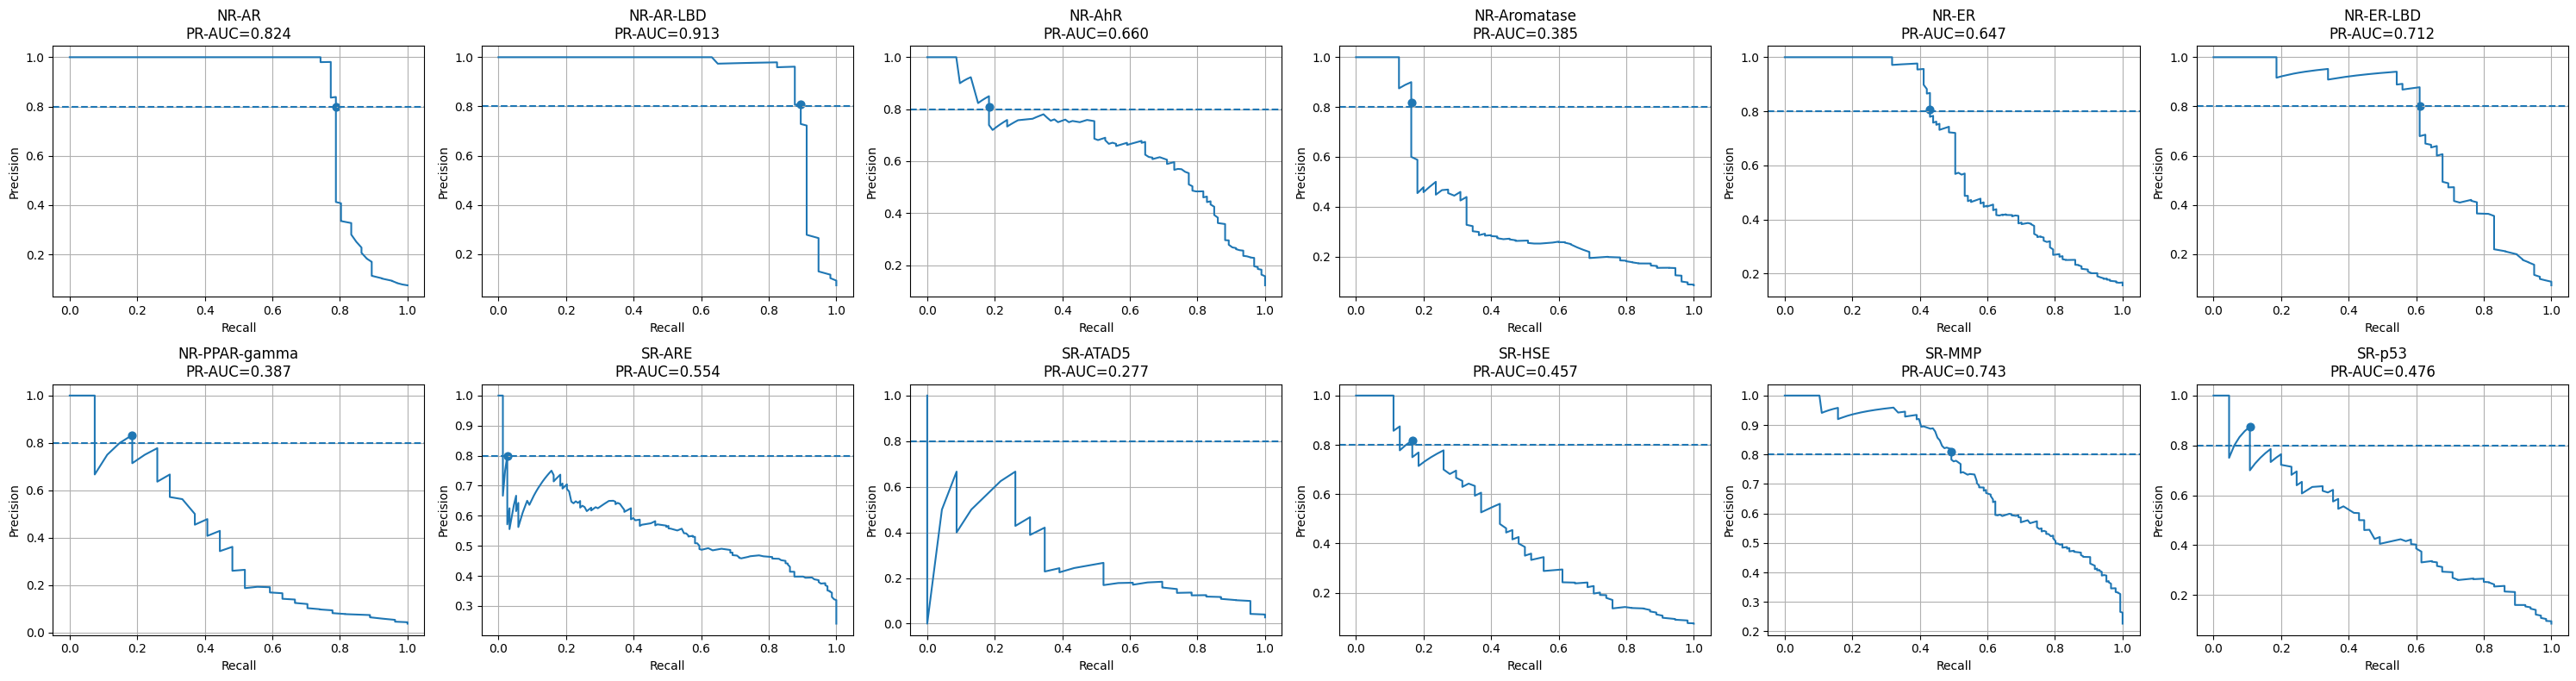

In [ ]:
plot_all_pr_curves(rf_v1_summary_df, rf_v1_curve_dict)

### (2) Plotting PR curve - ver2. plot Precision + Recall and threshold together for PR curve
(here result_df was used for plotting - last values are missing due to missing threshold)

In [ ]:
def summarize_multitarget_recall_at_precision(predictions_df, min_precision=0.8):
    rows = []
    curve_dict = {}

    for target, tmp in predictions_df.groupby("target"):  # groupby("target"): “target별로 쪼개진 여러 개의 df”를 순회 -> target = 그룹 이름, tmp = 그 그룹에 해당하는 df
        y_true = tmp["y_true"].values
        y_score = tmp["y_prob"].values

        # 클래스 하나뿐이면 skip
        if len(np.unique(y_true)) < 2:
            rows.append({
                "target": target,
                "n_test": len(tmp),
                "positive_ratio_test": np.mean(y_true),
                "pr_auc": np.nan,
                "best_threshold": np.nan,
                "precision_at_best_threshold": np.nan,
                "recall_at_precision_constraint": np.nan,
                "status": "skip_one_class"
            })
            continue

        out = get_recall_at_precision(  # 함수는 한 번 정의해두면, 같은 스코프 안에서는 언제든지 호출 가능하다 - 단, 그 함수가 먼저 정의되어 있어야 한다
            y_true=y_true,
            y_score=y_score,
            min_precision=min_precision
        )

        rows.append({
            "target": target,
            "n_test": len(tmp),
            "positive_ratio_test": np.mean(y_true),
            "pr_auc": out["pr_auc"],
            "best_threshold": out["best_threshold"],
            "precision_at_best_threshold": out["best_precision"],
            "recall_at_precision_constraint": out["best_recall"],
            "status": "ok" if not np.isnan(out["best_threshold"]) else "no_threshold_meets_constraint"
        })
                              # only here is different (added "result_df" instead of "curve_df")
        curve_dict[target] = out["result_df"] # 각 타겟의 PR curve 원자료를 담아둔 딕셔너리 (threshold, precision, recall 이 담겨있음)
                                              # 특정 target의 PR curve 그리기 / threshold별 precision/recall 변화 보기 / 왜 어떤 target은 precision >= 0.8을 만족 못하는지 확인
    summary_df = pd.DataFrame(rows).sort_values("target").reset_index(drop=True)
    return summary_df, curve_dict

In [ ]:
# get_best_threshold_by_precision_constraint
# 1. rf v1
rf_v1_summary_df, rf_v1_curve_dict = summarize_multitarget_recall_at_precision(rf_scaffold_v1_desc_predictions_df, min_precision=0.8)
rf_v1_summary_df

# Add mean row
rf_v1_summary_df.loc["mean"] = rf_v1_summary_df.mean(numeric_only=True)
rf_v1_summary_df

,target,n_test,positive_ratio_test,pr_auc,best_threshold,precision_at_best_threshold,recall_at_precision_constraint,status
0,NR-AR,882,0.074830,0.824339,0.173333,0.800000,0.787879,ok
1,NR-AR-LBD,784,0.072704,0.913202,0.193333,0.809524,0.894737,ok
2,NR-AhR,760,0.122368,0.659696,0.533333,0.809524,0.182796,ok
3,NR-Aromatase,651,0.084485,0.384582,0.533333,0.818182,0.163636,ok
4,NR-ER,684,0.156433,0.646949,0.436547,0.807018,0.429907,ok
5,NR-ER-LBD,805,0.073292,0.712124,0.340000,0.800000,0.610169,ok
6,NR-PPAR-gamma,738,0.036585,0.386561,0.316667,0.833333,0.185185,ok
7,SR-ARE,635,0.240945,0.553816,0.696667,0.800000,0.026144,ok
8,SR-ATAD5,831,0.027677,0.277393,NaN,NaN,NaN,no_threshold_meets_constraint
9,SR-HSE,722,0.074792,0.456793,0.390000,0.818182,0.166667,ok


In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd

def plot_all_pr_curves(summary_df, curve_dict, ncols=4):
    targets = sorted(curve_dict.keys())
    n_targets = len(targets)
    nrows = math.ceil(n_targets / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, target in zip(axes, targets):
        df = curve_dict[target].copy()
        row = summary_df[summary_df["target"] == target].iloc[0]

        ax.plot(df["recall"], df["precision"])
        ax.axhline(0.8, linestyle="--")

        if not pd.isna(row["best_threshold"]):
            ax.scatter(
                row["recall_at_precision_constraint"],  # X
                row["precision_at_best_threshold"],     # Y
                s=40                                    # “precision ≥ 0.8 조건을 만족하는 지점들 중에서 recall이 최대인 단 하나의 point”
            )

        sc = ax.scatter(  # Here is added - scale bar
        df["recall"],
        df["precision"],
        c=df["threshold"],
        cmap="viridis",
        s=5
        )
        plt.colorbar(sc, label="threshold")

        ax.set_title(f"{target}\nPR-AUC={row['pr_auc']:.3f}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.grid(True)

    # 남는 subplot 숨기기
    for ax in axes[n_targets:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

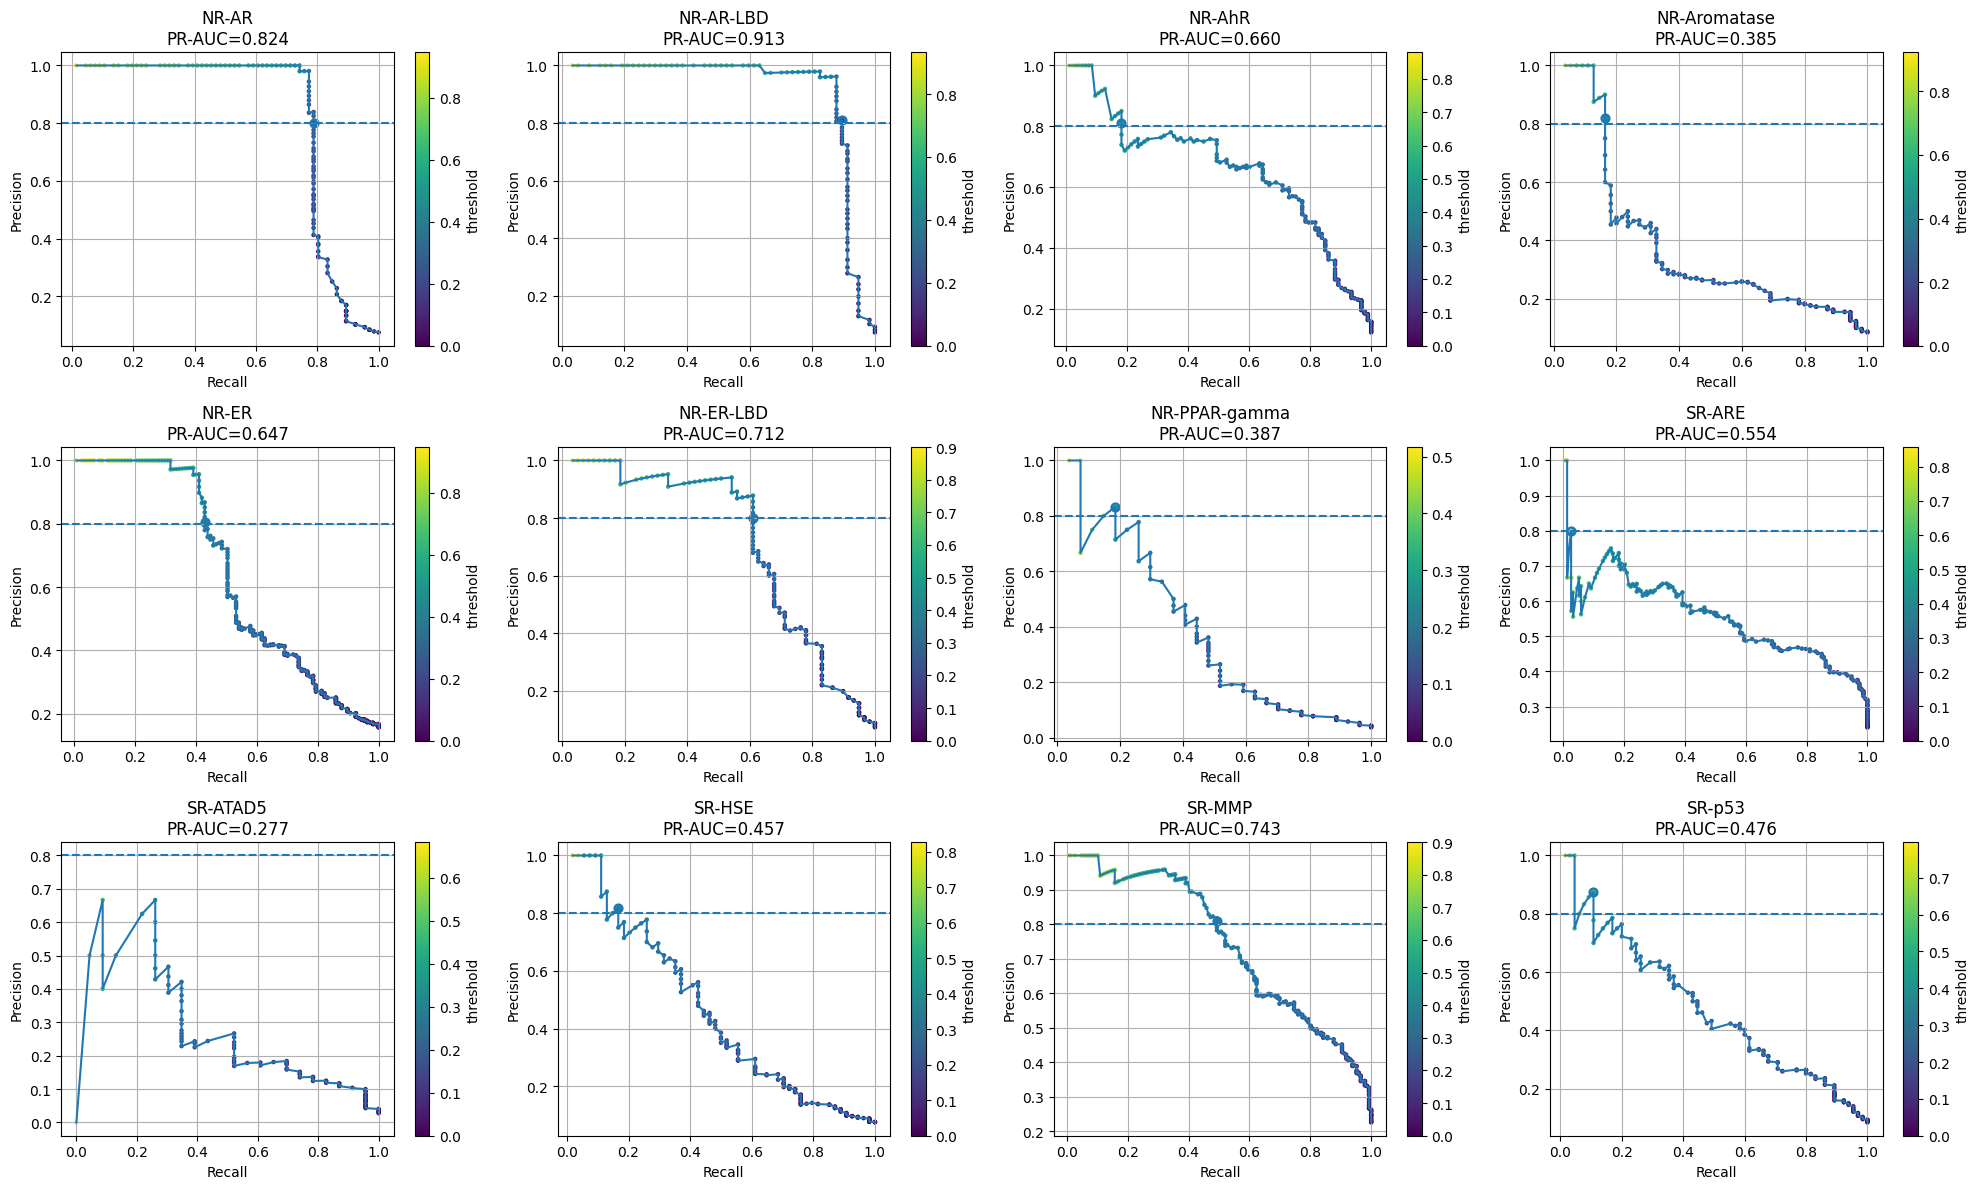

In [ ]:
plot_all_pr_curves(rf_v1_summary_df, rf_v1_curve_dict)

## 2. Performance comparison - (3-2) Precision / recall calculation - LightGBM v1

In [ ]:
# get_best_threshold_by_precision_constraint
# 2. lg v1
lg_v1_summary_df, lg_v1_curve_dict = summarize_multitarget_recall_at_precision(lg_scaffold_v1_desc_predictions_df, min_precision=0.8)
lg_v1_summary_df

# Add mean row
lg_v1_summary_df.loc["mean"] = lg_v1_summary_df.mean(numeric_only=True)
lg_v1_summary_df

,target,n_test,positive_ratio_test,pr_auc,best_threshold,precision_at_best_threshold,recall_at_precision_constraint,status
0,NR-AR,882.000000,0.074830,0.808975,0.379817,0.806452,0.757576,ok
1,NR-AR-LBD,784.000000,0.072704,0.899695,0.280624,0.806452,0.877193,ok
2,NR-AhR,760.000000,0.122368,0.646659,0.805217,0.800000,0.387097,ok
3,NR-Aromatase,651.000000,0.084485,0.334399,0.958165,0.800000,0.145455,ok
4,NR-ER,684.000000,0.156433,0.648996,0.843783,0.800000,0.448598,ok
5,NR-ER-LBD,805.000000,0.073292,0.682107,0.849288,0.809524,0.576271,ok
6,NR-PPAR-gamma,738.000000,0.036585,0.310543,0.761053,0.833333,0.185185,ok
7,SR-ARE,635.000000,0.240945,0.562375,0.954365,0.833333,0.032680,ok
8,SR-ATAD5,831.000000,0.027677,0.272337,0.982999,1.000000,0.043478,ok
9,SR-HSE,722.000000,0.074792,0.407364,0.833820,0.800000,0.222222,ok


## 2. Performance comparison - (3-3) Precision / recall calculation - LightGBM v2

In [ ]:
# get_best_threshold_by_precision_constraint
# 3. lg v2
lg_v2_summary_df, lg_v2_curve_dict = summarize_multitarget_recall_at_precision(lg_scaffold_v2_desc_predictions_df, min_precision=0.8)

# Add mean row
lg_v2_summary_df.loc["mean"] = lg_v2_summary_df.mean(numeric_only=True)
lg_v2_summary_df

,target,n_test,positive_ratio_test,pr_auc,best_threshold,precision_at_best_threshold,recall_at_precision_constraint,status
0,NR-AR,882.000000,0.074830,0.797595,0.059175,0.806452,0.757576,ok
1,NR-AR-LBD,784.000000,0.072704,0.902053,0.015320,0.806452,0.877193,ok
2,NR-AhR,760.000000,0.122368,0.646453,0.787855,0.800000,0.344086,ok
3,NR-Aromatase,651.000000,0.084485,0.375567,0.980274,0.818182,0.163636,ok
4,NR-ER,684.000000,0.156433,0.627526,0.839870,0.803571,0.420561,ok
5,NR-ER-LBD,805.000000,0.073292,0.692148,0.810412,0.813953,0.593220,ok
6,NR-PPAR-gamma,738.000000,0.036585,0.324978,0.774684,0.833333,0.185185,ok
7,SR-ARE,635.000000,0.240945,0.594223,0.972270,0.833333,0.032680,ok
8,SR-ATAD5,831.000000,0.027677,0.335675,0.997653,1.000000,0.043478,ok
9,SR-HSE,722.000000,0.074792,0.442484,0.829395,0.800000,0.296296,ok


## 2. Performance comparison - (4) Compare PR-AUC / Recall@precision≥0.8

In [ ]:
# PR_AUC

dfs = [rf_scaffold_v1_desc_results_df, lg_scaffold_v1_desc_results_df, lg_scaffold_v2_desc_results_df]
dfs_selected = []
names = ["rf_v1_scaf_desc", "lg_v1_scaf_desc", "lg_v2_scaf_desc"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    temp = df.set_index("target")[["pr_auc"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_pr_auc_scaffold_desc_df = pd.concat(dfs_selected, axis=1).reset_index()


# Add mean row
results_pr_auc_scaffold_desc_df.loc["pr_auc_mean"] = results_pr_auc_scaffold_desc_df.mean(numeric_only=True) # index = mean이 되고 target에 NaN이 채워짐
results_pr_auc_scaffold_desc_df

,target,rf_v1_scaf_desc,lg_v1_scaf_desc,lg_v2_scaf_desc
0,SR-HSE,0.458791,0.411154,0.446320
1,NR-AR,0.823111,0.809378,0.798098
2,SR-ARE,0.556286,0.565210,0.597233
3,NR-Aromatase,0.385335,0.338166,0.379006
4,NR-ER-LBD,0.712253,0.683935,0.693787
5,NR-AhR,0.658575,0.648481,0.648244
6,SR-MMP,0.741710,0.739541,0.755978
7,NR-ER,0.647125,0.649858,0.628491
8,NR-PPAR-gamma,0.390557,0.314895,0.330569
9,SR-p53,0.478734,0.404480,0.438923


In [ ]:
# PR_AUC:: rf_v1 > lg_v2 > lg_v1 (ROC와 동일)

In [ ]:
# Recall@precision≥0.8

dfs = [rf_v1_summary_df, lg_v1_summary_df, lg_v2_summary_df]
dfs_selected = []
names = ["rf_v1_scaf_desc", "lg_v1_scaf_desc", "lg_v2_scaf_desc"]

for df, name in zip(dfs, names):  # zip은 여러 개의 리스트를 “같은 위치끼리 묶어주는” 함수입니다
    df.iloc[12, 0] = "mean"
    temp = df.set_index("target")[["recall_at_precision_constraint"]]
    temp.columns = [f"{name}"]
    dfs_selected.append(temp)

results_recall_scaffold_desc_df = pd.concat(dfs_selected, axis=1).reset_index()
results_recall_scaffold_desc_df

,target,rf_v1_scaf_desc,lg_v1_scaf_desc,lg_v2_scaf_desc
0,NR-AR,0.787879,0.757576,0.757576
1,NR-AR-LBD,0.894737,0.877193,0.877193
2,NR-AhR,0.182796,0.387097,0.344086
3,NR-Aromatase,0.163636,0.145455,0.163636
4,NR-ER,0.429907,0.448598,0.420561
5,NR-ER-LBD,0.610169,0.576271,0.593220
6,NR-PPAR-gamma,0.185185,0.185185,0.185185
7,SR-ARE,0.026144,0.032680,0.032680
8,SR-ATAD5,NaN,0.043478,0.043478
9,SR-HSE,0.166667,0.222222,0.296296


In [ ]:
# Recall@precision≥0.8: rf_v1 > lg_v2 > lg_v1 (PR와 동일)- but rf did not work for SR-ATAD5

In [ ]:
# # [1] 그래서 어떤 모델을 선택할것인가?
# # -> “목적이 뭐냐”에 따라 선택이 달라짐

#  케이스 1: 실제 독성 스크리닝 (false positive 줄이고 싶다) - hit discovery / screening
# → recall@precision≥0.8 기준으로 선택
# (우리는 이 경우가 더 우선적 고려 기준)

#  케이스 2: 전체적인 모델 품질 (논문 / general benchmark) - ranking / scoring / downstream model
# → PR-AUC 기준으로 선택

# 두 경우 모두 RF v1 (rf_v1_scaf_desc)가 가장 좋음

# # 실무에서 자주 하는 방법 (추천)
# # 만약 두 케이스에서 우선인 모델이 다르면, 둘 다 버리지 말고 이렇게 씀:
# 방법 1: 모델 ensemble - 두 모델의 평균
# 방법 2: 2-stage - A모델(recall높은애)로 high precision filtering -> B모델(PR 높은애)로 ranking

In [ ]:
# # [2] Random forest 파라미터를 바꾸면 SR-ATAD5에서 값이 나올 수 있냐

# NaN이 나왔다는 건 “RF라는 알고리즘이 절대 안 된다”가 아니라,
# 현재 하이퍼파라미터 + 현재 feature + 현재 split에서 안 나온 것일 뿐이야.

# # 어떤 파라미터가 영향이 크냐

# SR-ATAD5 같은 타겟에서 high-precision point를 만들고 싶으면 RF에서 이런 것들이 중요해.

# max_depth
# 너무 얕으면 구분력이 부족해서 positive가 안 모임
# 너무 깊으면 noisy하게 쪼개져서 generalization이 나빠질 수 있음
# min_samples_leaf
# 너무 작으면 확률이 들쭉날쭉
# 조금 키우면 score가 더 안정적일 수 있음
# min_samples_split
# 트리 분할 조건을 조절해서 과도한 분할 방지
# n_estimators
# 늘리면 예측 안정성이 좋아질 수 있음
# max_features
# feature subsampling 정도가 바뀌면 성능이 꽤 달라질 수 있음
# class_weight
# 특히 positive가 적으면 중요
# balanced 또는 target-specific weighting이 high-recall/high-precision trade-off에 영향 줄 수 있음

In [ ]:
# ==> 결론: PR과 Recall@Precision>=0.8 두 기준 모두 random forest v1이 우세하므로 이 모델을 대상으로 튜닝 진행할것.
# 다만 SR-ATAD5에서 random forest가 Recall@Precision>=0.8를 만족하는 threshold를 찾지 못했으므로
# tuning 과정에서 이 endpoint에 주의하면서 진행하기 (필요하면 target별 best model 선택도 고려?)

# Phase C. tuning

- 튜닝은 이 단계에서 합니다.

- 추천 순서:

1. scaffold 기준으로 최종 쓸 feature set 결정
2. scaffold 기준으로 최종 쓸 모델 후보 결정
3. 그 후보만 tuning

- 즉: random split에서 성능 좋다고 무조건 tuning하지 말고 scaffold split에서 살아남는 모델 위주로 tuning하는 게 더 실무적입니다.

- tuning은 언제 하는 게 좋냐: baseline 비교가 끝난 뒤에 tuning
- 실무에서는: 먼저) default / strong default로 baseline / 나중) 상위 모델만 tuning

- 하지만 실무적으로 간소화할 때 시간이 없으면 이렇게도 많이 합니다:

1. baseline은 random/scaffold 둘 다 strong default로 비교
2. 최종 보고용인 scaffold만 제대로 tuning
3. random은 참고용으로만 둠


# CV 버전 scaffold
- 다른 함수들과 합쳐서도 가능한지 refine
- array랑 dataframe 정리하기 - scaffold는 array 기준임
- 나중에는 이거랑 앞에 global 버전까지 합칠수있는지 알아보기
- Global scaffold split - 최종 보고 시, 최종 성능 리포트 (cf. CV: 5개 덩어리로 나눠서 반복평가)

In [ ]:
# 이거 다음에 흐름 확인) 최종 모델 1개 결정 -> 튜닝 (그냥 아래 simple tuning + scaffold로도 충분한지) -> 그러면 끝? 뭐를 보고 해야하는지?
# 전체적인 비교 표 만들기? 그래프?
# 일단 24조합먼저하고 그다음에 더 세부적으로 2차 튜닝 진행

In [ ]:
# Define Data
valid_df = df_w_fp_desc[df_w_fp_desc["is_valid"] & df_w_fp_desc["desc_valid"]].copy()
X_all = X_df.copy()
X_all

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,NumAromaticRings,FractionCSP3,HeavyAtomCount,FormalCharge
0,0,1,0,0,0,0,0,0,0,0,...,2.6355,92.95,5.0,5.0,6.0,2.0,2.0,0.294118,23.0,0.0
1,0,1,0,0,0,0,0,0,0,0,...,1.8598,46.25,2.0,2.0,2.0,1.0,1.0,0.333333,12.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,3.6009,6.48,0.0,2.0,7.0,1.0,0.0,0.833333,15.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,2.0405,6.48,0.0,2.0,3.0,1.0,0.0,0.750000,11.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,1.6504,6.48,0.0,2.0,2.0,1.0,0.0,0.714286,10.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8036,0,0,0,0,0,0,0,0,0,0,...,2.1294,18.07,0.0,1.0,2.0,2.0,2.0,0.111111,11.0,0.0
8037,0,0,0,0,0,0,0,0,0,0,...,5.2051,0.00,0.0,3.0,2.0,3.0,3.0,0.000000,15.0,0.0
8038,0,0,1,0,0,0,0,0,0,0,...,4.3934,3.24,0.0,2.0,2.0,3.0,1.0,0.733333,17.0,0.0
8039,0,0,0,0,0,0,0,0,0,0,...,4.6090,0.00,0.0,4.0,3.0,2.0,2.0,0.000000,12.0,0.0


In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def make_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    return scaffold

In [ ]:
# 1) outer hold-out split 만드는 함수 (Outer split: scaffold hold-out)

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, ParameterGrid
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier


def make_scaffold_holdout_split(valid_df, X_all, make_scaffold, test_size=0.2, random_state=42):
    df = valid_df.copy()
    df["scaffold"] = df["canonical_smiles"].apply(make_scaffold)

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state) # GSS: “같은 scaffold는 쪼개지지 않고 한 덩어리로 유지된다” (전부 train or 전부 test)-> data leakage 방지
    train_idx, test_idx = next(gss.split(df, groups=df["scaffold"]))                    # scaffold group 단위로 통째로 train/test 배정
                       # -> train /test로 scaffold 기준으로 나눠서 행위치 기반으로 인덱스를 분리함.
    train_df = df.iloc[train_idx].copy()  # 행 위치 인덱스 -> 원래 DataFrame에서 train/test data 가져오기
    test_df = df.iloc[test_idx].copy()

    X_train_all = X_all.iloc[train_idx].copy()
    X_test_all = X_all.iloc[test_idx].copy()

    return train_df, test_df, X_train_all, X_test_all

In [ ]:
# 2) recall@precision 계산 함수
# 위의 함수랑 다른가? 합칠수있나?
def get_recall_at_precision(y_true, y_score, min_precision=0.8):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    pr_auc = average_precision_score(y_true, y_score)

    # sklearn: len(precision) = len(recall) = len(thresholds) + 1
    precision_t = precision[:-1]
    recall_t = recall[:-1]

    if len(thresholds) == 0:
        return {
            "best_recall": np.nan,
            "best_threshold": np.nan,
            "best_precision": np.nan,
            "pr_auc": pr_auc
        }

    valid_mask = precision_t >= min_precision

    if not np.any(valid_mask):
        return {
            "best_recall": np.nan,
            "best_threshold": np.nan,
            "best_precision": np.nan,
            "pr_auc": pr_auc
        }

    valid_idx = np.where(valid_mask)[0]
    best_idx = valid_idx[np.argmax(recall_t[valid_idx])]

    return {
        "best_recall": recall_t[best_idx],
        "best_threshold": thresholds[best_idx],
        "best_precision": precision_t[best_idx],
        "pr_auc": pr_auc
    }

In [ ]:
# 3) train 내부 CV로 RF tuning - refined: checkpoint save, verbose included (RF 내부 트리 생성만 병렬화 / 파라미터 조합 탐색은 직렬 / 타깃 12개도 직렬)
# best params 찾기 (Inner CV for model selection)
import os
import json
import time
import pickle
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, ParameterGrid
from sklearn.metrics import roc_auc_score, average_precision_score


def tune_multitarget_random_forest_on_train_cv(
    train_df,
    X_train_all,
    target_cols,
    param_grid,
    n_splits=5,
    random_state=42,
    selection_metric="pr_auc",
    min_precision=0.8,
    nan_recall_fill=0.0,
    checkpoint_dir="rf_tuning_checkpoints",
    resume=True,
    verbose=1,
    rf_n_jobs=-1
):
    """
    Multi-target RF tuning with:
    - manual CV over ParameterGrid
    - checkpoint save/load
    - resume from previous run
    - verbose progress logs

    Parameters
    ----------
    resume : bool
        True면 checkpoint를 읽어서 이미 끝난 target은 건너뜀
    verbose : int
        0 = silent
        1 = target 단위 로그
        2 = param 단위 로그
        3 = fold 단위 로그
    rf_n_jobs : int
        RandomForestClassifier 내부 병렬화 설정
        현재 구조에서는 -1 또는 적당한 양수 추천
    """

    os.makedirs(checkpoint_dir, exist_ok=True)

    results_csv_path = os.path.join(checkpoint_dir, "rf_tuning_results_partial.csv")
    params_pkl_path = os.path.join(checkpoint_dir, "rf_best_params_by_target.pkl")
    done_targets_json_path = os.path.join(checkpoint_dir, "rf_done_targets.json")

    # 입력 X 정리
    if isinstance(X_train_all, pd.DataFrame):
        X_train_all = X_train_all.to_numpy()

    # checkpoint 로드
    if resume and os.path.exists(results_csv_path):
        existing_results_df = pd.read_csv(results_csv_path)
    else:
        existing_results_df = pd.DataFrame()

    if resume and os.path.exists(params_pkl_path):
        with open(params_pkl_path, "rb") as f:
            best_params_by_target = pickle.load(f)
    else:
        best_params_by_target = {}

    if resume and os.path.exists(done_targets_json_path):
        with open(done_targets_json_path, "r", encoding="utf-8") as f:
            done_targets = set(json.load(f))
    else:
        done_targets = set()

    results = []
    if not existing_results_df.empty:
        results = existing_results_df.to_dict(orient="records")

    total_targets = len(target_cols)
    param_list = list(ParameterGrid(param_grid))
    total_param_combinations = len(param_list)

    if verbose >= 1:
        print("=" * 80)
        print("RF tuning started")
        print(f"Total targets: {total_targets}")
        print(f"Param combinations per target: {total_param_combinations}")
        print(f"CV folds: {n_splits}")
        print(f"Resume mode: {resume}")
        print(f"Already completed targets: {len(done_targets)}")
        print("=" * 80)

    for target_idx, target in enumerate(target_cols, start=1):
        if target in done_targets:
            if verbose >= 1:
                print(f"[{target_idx}/{total_targets}] SKIP already completed target: {target}")
            continue

        target_start_time = time.time()

        if verbose >= 1:
            print("\n" + "-" * 80)
            print(f"[{target_idx}/{total_targets}] Start target: {target}")

        mask = train_df[target].notna()
        task_df = train_df.loc[mask].copy()
        y_task = task_df[target].astype(int).values

        if len(task_df) == 0:
            print(f"SKIP: {target} (no samples)")
            done_targets.add(target)
            _save_rf_checkpoints(results, best_params_by_target, done_targets,
                                 results_csv_path, params_pkl_path, done_targets_json_path)
            continue

        if len(np.unique(y_task)) < 2:
            print(f"SKIP: {target} (only one class)")
            done_targets.add(target)
            _save_rf_checkpoints(results, best_params_by_target, done_targets,
                                 results_csv_path, params_pkl_path, done_targets_json_path)
            continue

        X_task = X_train_all[mask]
        groups = task_df["scaffold"].values

        if pd.Series(groups).nunique() < n_splits:
            print(f"SKIP: {target} (unique scaffolds < n_splits)")
            done_targets.add(target)
            _save_rf_checkpoints(results, best_params_by_target, done_targets,
                                 results_csv_path, params_pkl_path, done_targets_json_path)
            continue

        sgkf = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        best_score = -np.inf
        best_params = None
        best_row = None

        for param_idx, params in enumerate(param_list, start=1):
            param_start_time = time.time()

            if verbose >= 2:
                print(f"\n  [Target {target}] Param {param_idx}/{total_param_combinations}: {params}")

            fold_scores = []
            valid_fold_count = 0

            for fold_idx, (tr_idx, val_idx) in enumerate(
                sgkf.split(X_task, y_task, groups=groups), start=1
            ):
                fold_start_time = time.time()

                X_tr = X_task[tr_idx]
                X_val = X_task[val_idx]
                y_tr = y_task[tr_idx]
                y_val = y_task[val_idx]

                if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
                    if verbose >= 3:
                        print(f"    Fold {fold_idx}/{n_splits}: skipped (only one class)")
                    continue

                model = RandomForestClassifier(
                    random_state=random_state,
                    n_jobs=rf_n_jobs,
                    **params
                )

                model.fit(X_tr, y_tr)
                y_prob = model.predict_proba(X_val)[:, 1]

                rap_out = get_recall_at_precision(
                    y_true=y_val,
                    y_score=y_prob,
                    min_precision=min_precision
                )

                recall_at_precision = rap_out["best_recall"]
                if np.isnan(recall_at_precision):
                    recall_at_precision_for_selection = nan_recall_fill
                else:
                    recall_at_precision_for_selection = recall_at_precision

                fold_result = {
                    "roc_auc": roc_auc_score(y_val, y_prob),
                    "pr_auc": average_precision_score(y_val, y_prob),
                    "recall_at_precision": recall_at_precision,
                    "recall_at_precision_for_selection": recall_at_precision_for_selection,
                    "best_threshold": rap_out["best_threshold"],
                    "best_precision": rap_out["best_precision"]
                }
                fold_scores.append(fold_result)
                valid_fold_count += 1

                if verbose >= 3:
                    fold_elapsed = time.time() - fold_start_time
                    print(
                        f"    Fold {fold_idx}/{n_splits} done "
                        f"(roc_auc={fold_result['roc_auc']:.4f}, "
                        f"pr_auc={fold_result['pr_auc']:.4f}, "
                        f"time={fold_elapsed:.1f}s)"
                    )

            if len(fold_scores) == 0:
                if verbose >= 2:
                    print("    No valid fold scores. Skip this param.")
                continue

            fold_df = pd.DataFrame(fold_scores)

            mean_roc_auc = fold_df["roc_auc"].mean()
            mean_pr_auc = fold_df["pr_auc"].mean()
            mean_recall_at_precision = fold_df["recall_at_precision"].mean(skipna=True)
            mean_recall_at_precision_for_selection = fold_df["recall_at_precision_for_selection"].mean()

            if selection_metric == "pr_auc":
                score = mean_pr_auc
            elif selection_metric == "recall_at_precision":
                score = mean_recall_at_precision_for_selection
            else:
                raise ValueError("selection_metric must be 'pr_auc' or 'recall_at_precision'")

            if verbose >= 2:
                param_elapsed = time.time() - param_start_time
                print(
                    f"    Param summary: valid_folds={valid_fold_count}, "
                    f"mean_roc_auc={mean_roc_auc:.4f}, "
                    f"mean_pr_auc={mean_pr_auc:.4f}, "
                    f"mean_recall_at_precision={mean_recall_at_precision:.4f}, "
                    f"selection_score={score:.4f}, "
                    f"time={param_elapsed/60:.2f} min"
                )

            if score > best_score:
                best_score = score
                best_params = params
                best_row = {
                    "target": target,
                    "n_samples": len(y_task),
                    "positive_ratio": y_task.mean(),
                    "cv_roc_auc_mean": mean_roc_auc,
                    "cv_pr_auc_mean": mean_pr_auc,
                    "cv_recall_at_precision_mean": mean_recall_at_precision,
                    "cv_recall_at_precision_for_selection_mean": mean_recall_at_precision_for_selection,
                    "selection_metric": selection_metric,
                    "selection_score": score,
                    "best_params": json.dumps(params, ensure_ascii=False)
                }

                if verbose >= 2:
                    print(f"    >>> New best score for {target}: {best_score:.4f}")

        if best_params is None:
            print(f"SKIP: {target} (no valid CV result)")
            done_targets.add(target)
            _save_rf_checkpoints(results, best_params_by_target, done_targets,
                                 results_csv_path, params_pkl_path, done_targets_json_path)
            continue

        results = [r for r in results if r["target"] != target]
        results.append(best_row)
        best_params_by_target[target] = best_params
        done_targets.add(target)

        _save_rf_checkpoints(
            results,
            best_params_by_target,
            done_targets,
            results_csv_path,
            params_pkl_path,
            done_targets_json_path
        )

        target_elapsed = time.time() - target_start_time

        if verbose >= 1:
            print(f"[DONE] target={target}")
            print(f"       best_score={best_score:.4f}")
            print(f"       best_params={best_params}")
            print(f"       elapsed={target_elapsed/60:.2f} min")
            print(f"       checkpoint saved to: {checkpoint_dir}")

    final_results_df = pd.DataFrame(results)

    if not final_results_df.empty:
        final_results_df = final_results_df.sort_values(
            by=["selection_score", "target"],
            ascending=[False, True]
        ).reset_index(drop=True)

    if verbose >= 1:
        print("\n" + "=" * 80)
        print("RF tuning finished")
        print(f"Completed targets: {len(done_targets)}/{total_targets}")
        print(f"Results saved in: {checkpoint_dir}")
        print("=" * 80)

    return final_results_df, best_params_by_target


def _save_rf_checkpoints(
    results,
    best_params_by_target,
    done_targets,
    results_csv_path,
    params_pkl_path,
    done_targets_json_path
):
    results_df = pd.DataFrame(results)
    results_df.to_csv(results_csv_path, index=False)

    with open(params_pkl_path, "wb") as f:
        pickle.dump(best_params_by_target, f)

    with open(done_targets_json_path, "w", encoding="utf-8") as f:
        json.dump(sorted(list(done_targets)), f, ensure_ascii=False, indent=2)

In [ ]:
# 1차 grid refined: 24조합 -> 2차 튜닝은 잘나온것 근처로 돌림 (n_estimator 늘려서)
rf_param_grid_small_v2 = {
    "n_estimators": [300],
    "max_depth": [None, 12],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.3],
    "class_weight": [None, "balanced"]
}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1) outer hold-out split
train_df, test_df, X_train_all, X_test_all = make_scaffold_holdout_split(
    valid_df=valid_df,
    X_all=X_all,
    make_scaffold=make_scaffold,
    test_size=0.2,
    random_state=42
)

# 2) inner CV tuning (train에서만 CV tuning)
rf_cv_results_df, rf_best_params_by_target = tune_multitarget_random_forest_on_train_cv(
    train_df=train_df,
    X_train_all=X_train_all,
    target_cols=target_cols,
    param_grid=rf_param_grid_small_v2,
    n_splits=5,
    random_state=42,
    selection_metric="pr_auc",   # 또는 "recall_at_precision"
    min_precision=0.8,
    nan_recall_fill=0.0,
    checkpoint_dir="/content/drive/MyDrive/rf_checkpoints",
    resume=True,
    verbose=2,
    rf_n_jobs=-1
)

[09:25:02] WARNING: not removing hydrogen atom without neighbors


RF tuning started
Total targets: 12
Param combinations per target: 24
CV folds: 5
Resume mode: True
Already completed targets: 10
[1/12] SKIP already completed target: SR-HSE
[2/12] SKIP already completed target: NR-AR
[3/12] SKIP already completed target: SR-ARE
[4/12] SKIP already completed target: NR-Aromatase
[5/12] SKIP already completed target: NR-ER-LBD
[6/12] SKIP already completed target: NR-AhR
[7/12] SKIP already completed target: SR-MMP
[8/12] SKIP already completed target: NR-ER
[9/12] SKIP already completed target: NR-PPAR-gamma
[10/12] SKIP already completed target: SR-p53

--------------------------------------------------------------------------------
[11/12] Start target: SR-ATAD5

  [Target SR-ATAD5] Param 1/24: {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
    Param summary: valid_folds=5, mean_roc_auc=0.8375, mean_pr_auc=0.4466, mean_recall_at_precision=0.3033, selection_score=0.4466, time=1.16 min
   

In [ ]:
rf_cv_results_df

,target,n_samples,positive_ratio,cv_roc_auc_mean,cv_pr_auc_mean,cv_recall_at_precision_mean,cv_recall_at_precision_for_selection_mean,selection_metric,selection_score,best_params
0,NR-ER,5511,0.100708,0.854114,0.662744,0.494758,0.494758,pr_auc,0.662744,"{""class_weight"": ""balanced"", ""max_depth"": null..."
1,SR-MMP,5259,0.144514,0.884556,0.658345,0.259774,0.259774,pr_auc,0.658345,"{""class_weight"": ""balanced"", ""max_depth"": null..."
2,NR-AhR,5910,0.109814,0.872754,0.576025,0.295126,0.295126,pr_auc,0.576025,"{""class_weight"": ""balanced"", ""max_depth"": null..."
3,NR-AR-LBD,6123,0.026621,0.897585,0.565397,0.522903,0.392178,pr_auc,0.565397,"{""class_weight"": ""balanced"", ""max_depth"": 12, ..."
4,NR-ER-LBD,6277,0.038872,0.865731,0.560611,0.356480,0.356480,pr_auc,0.560611,"{""class_weight"": ""balanced"", ""max_depth"": null..."
5,SR-ARE,5273,0.145079,0.747854,0.484777,0.232111,0.232111,pr_auc,0.484777,"{""class_weight"": null, ""max_depth"": null, ""max..."
6,SR-ATAD5,6399,0.034380,0.870233,0.469386,0.509751,0.407801,pr_auc,0.469386,"{""class_weight"": ""balanced"", ""max_depth"": null..."
7,NR-AR,6535,0.029839,0.821912,0.446774,0.309146,0.231859,pr_auc,0.446774,"{""class_weight"": null, ""max_depth"": null, ""max..."
8,SR-HSE,5851,0.048368,0.832574,0.417389,0.284040,0.284040,pr_auc,0.417389,"{""class_weight"": ""balanced"", ""max_depth"": 12, ..."
9,NR-Aromatase,5287,0.043503,0.774900,0.375928,0.155217,0.155217,pr_auc,0.375928,"{""class_weight"": null, ""max_depth"": 12, ""max_f..."


In [ ]:
rf_best_params_by_target

{'SR-HSE': {'class_weight': 'balanced',
  'max_depth': 12,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'n_estimators': 300},
 'NR-AR': {'class_weight': None,
  'max_depth': None,
  'max_features': 0.3,
  'min_samples_leaf': 2,
  'n_estimators': 300},
 'SR-ARE': {'class_weight': None,
  'max_depth': None,
  'max_features': 0.3,
  'min_samples_leaf': 2,
  'n_estimators': 300},
 'NR-Aromatase': {'class_weight': None,
  'max_depth': 12,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'n_estimators': 300},
 'NR-ER-LBD': {'class_weight': 'balanced',
  'max_depth': None,
  'max_features': 0.3,
  'min_samples_leaf': 2,
  'n_estimators': 300},
 'NR-AhR': {'class_weight': 'balanced',
  'max_depth': None,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'n_estimators': 300},
 'SR-MMP': {'class_weight': 'balanced',
  'max_depth': None,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'n_estimators': 300},
 'NR-ER': {'class_weight': 'balanced',
  'max_depth': None,
  'max_feat

In [ ]:
# 4)선택된 params로 train 전체 재학습 후 holdout test 평가
def evaluate_multitarget_random_forest_on_holdout(
    train_df,
    test_df,
    X_train_all,
    X_test_all,
    target_cols,
    best_params_by_target,
    random_state=42,
    min_precision=0.8
):
    results = []
    models = {}

    for target in target_cols:
        if target not in best_params_by_target:
            print(f"SKIP: {target} (no tuned params)")
            continue

        train_mask = train_df[target].notna()
        test_mask = test_df[target].notna()

        task_train_df = train_df.loc[train_mask].copy()
        task_test_df = test_df.loc[test_mask].copy()

        if len(task_train_df) == 0 or len(task_test_df) == 0:
            print(f"SKIP: {target} (empty train/test after target filtering)")
            continue

        X_train = X_train_all[train_mask.values]
        X_test = X_test_all[test_mask.values]
        y_train = task_train_df[target].astype(int).values
        y_test = task_test_df[target].astype(int).values

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"SKIP: {target} (train/test has only one class)")
            continue

        model = RandomForestClassifier(
            random_state=random_state,
            n_jobs=-1,
            **best_params_by_target[target]
        )

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

        rap_out = get_recall_at_precision(
            y_true=y_test,
            y_score=y_prob,
            min_precision=min_precision
        )

        results.append({
            "target": target,
            "train_n": len(y_train),
            "test_n": len(y_test),
            "train_positive_ratio": y_train.mean(),
            "test_positive_ratio": y_test.mean(),
            "test_roc_auc": roc_auc_score(y_test, y_prob),
            "test_pr_auc": average_precision_score(y_test, y_prob),
            "test_recall_at_precision": rap_out["best_recall"],
            "test_precision_at_best_threshold": rap_out["best_precision"],
            "test_best_threshold": rap_out["best_threshold"],
            "best_params": best_params_by_target[target]
        })

        models[target] = model

    return pd.DataFrame(results), models

In [ ]:
cv_results_df[[
    "target",
    "cv_pr_auc_mean",
    "cv_recall_at_precision_mean",
    "selection_metric",
    "selection_score"
]]

In [ ]:
cv_results_df.sort_values("cv_recall_at_precision_mean")

In [ ]:
# holdout evaluation (다 고른 뒤에만 hold-out test 평가)
holdout_results_df, final_models = evaluate_multitarget_random_forest_on_holdout(
    train_df=train_df,
    test_df=test_df,
    X_train_all=X_train_all,
    X_test_all=X_test_all,
    target_cols=target_cols,
    best_params_by_target=best_params_by_target,
    random_state=42,
    min_precision=0.8
)

In [ ]:
# Tuning was done but rather than putting more effort in second tuning to increase only slight performance, move on to DL (neural network)

# Additional analysis. Baseline model - XAI
* XAI: Explainable AI, 모델이 왜 그런 예측을 했는지 사람이 이해할 수 있게 설명하는 기술
* 방법 종류: SHAP (가장 많이 씀), LIME, Feature importance, permutation importance

In [ ]:
# # Feature importance 중 오해: “중요하다 = 원인이다” (X) / “중요하다 = 예측에 많이 쓰였다” (O)
# Morgan FP: RDKit로 substructure 복원: 특정 bit → 어떤 atom 중심 substructure
# Descriptor: 자체로 의미 해석 가능

# 1. logistic regression: 계수(coef_) 자체가 중요도
# coef = model.coef_[0]
# + 값: positive 영향 / - 값: negative 영향 -> RDKit 추가 전/후 비교하면 의미 큼
# 2. Random forest/ lightGBM:
# model.feature_importances_    -> 하지만 이건 bias 잇음 (특히 RF)
# 추천: SHAP


In [ ]:

### 이거 feature importance 할때 다시 보기
# 3/31 챗지피티 아래 질문에 대한 답 참고
### 근데 그럼 보통 multi target일때 feature importance를 할때는 모든 target에서 나온 모델의 평균을 활용하나? 이전에 쓰던 방식에서는 그럼 model을 불렀을때 사실 마지막 컬럼의 target만을 고려하고 있었던 거겠네?
#근데 그럼 보통 multi target일때 feature importance를 할때는 모든 target에서 나온 모델의 평균을 활용하나?
#이전에 쓰던 방식에서는 그럼 model을 불렀을때 사실 마지막 컬럼의 target만을 고려하고 있었던 거겠네?
# --> 챗지피티 다시 공부하기!!!!!!!!!


In [ ]:
# Feature importance
# 1. 전체 중 top feature 확인
import numpy as np
from rdkit.Chem import AllChem, Draw

importances = rf_fp_desc_model.feature_importances_
feature_names = X_df.columns

top_idx = np.argsort(importances)[-20:][::-1]

for i in top_idx:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

RingCount: 0.0352
MolWt: 0.0258
HeavyAtomCount: 0.0246
fp_84: 0.0218
fp_519: 0.0202
fp_1060: 0.0183
fp_1162: 0.0172
FractionCSP3: 0.0159
MolLogP: 0.0159
fp_529: 0.0151
fp_1274: 0.0140
fp_1325: 0.0130
TPSA: 0.0125
fp_1436: 0.0112
fp_622: 0.0112
fp_1738: 0.0111
fp_1019: 0.0109
NumRotatableBonds: 0.0104
NumAromaticRings: 0.0094
NumHAcceptors: 0.0093


In [ ]:
# 2. fingerprint bit 만 따로 해석
fp_features = []

for i in top_idx:
    fname = feature_names[i]
    if str(fname).startswith("fp_"):
        bit_id = int(str(fname).replace("fp_", ""))
        fp_features.append((i, fname, bit_id, importances[i]))

fp_features.reverse() # 원본 리스트 자체를 뒤집기

[(np.int64(84), 'fp_84', 84, np.float64(0.02177216695235986)),
 (np.int64(519), 'fp_519', 519, np.float64(0.020207561962379904)),
 (np.int64(1060), 'fp_1060', 1060, np.float64(0.01831302701333047)),
 (np.int64(1162), 'fp_1162', 1162, np.float64(0.01723839344880088)),
 (np.int64(529), 'fp_529', 529, np.float64(0.015139081482730372)),
 (np.int64(1274), 'fp_1274', 1274, np.float64(0.014048370091465466)),
 (np.int64(1325), 'fp_1325', 1325, np.float64(0.012950953982413025)),
 (np.int64(1436), 'fp_1436', 1436, np.float64(0.011193133775705839)),
 (np.int64(622), 'fp_622', 622, np.float64(0.011172904898098735)),
 (np.int64(1738), 'fp_1738', 1738, np.float64(0.01105218479092335)),
 (np.int64(1019), 'fp_1019', 1019, np.float64(0.010866122071719084))]


=== fp_84 / importance=0.0218 ===
row=64, smiles=C#CC1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4[C@H]3CC[C@@]21CC


[19:31:41] DEPRECATION WARNING: please use MorganGenerator


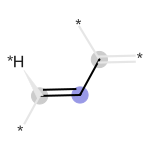

row=80, smiles=C#C[C@]1(O)C=C[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4[C@H]3CC[C@@]21CC


[19:31:41] DEPRECATION WARNING: please use MorganGenerator


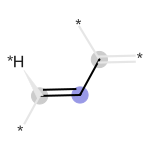

row=82, smiles=C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=C/C(=N/O)CC[C@@H]4[C@H]3CC[C@@]21CC


[19:31:41] DEPRECATION WARNING: please use MorganGenerator


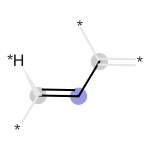


=== fp_519 / importance=0.0202 ===
row=11, smiles=Br.COc1ccc2c(c1)[C@@]13CCCCC1[C@@H](C2)N(C)CC3.O


[19:31:41] DEPRECATION WARNING: please use MorganGenerator


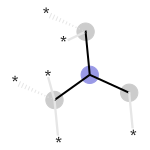

row=64, smiles=C#CC1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4[C@H]3CC[C@@]21CC


[19:31:41] DEPRECATION WARNING: please use MorganGenerator


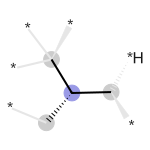

row=79, smiles=C#C[C@@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]3CC[C@@]21C


[19:31:41] DEPRECATION WARNING: please use MorganGenerator


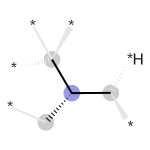


=== fp_1060 / importance=0.0183 ===
row=11, smiles=Br.COc1ccc2c(c1)[C@@]13CCCCC1[C@@H](C2)N(C)CC3.O


[19:31:41] DEPRECATION WARNING: please use MorganGenerator


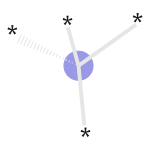

row=12, smiles=Br.C[C@@H]1[C@@H]2Cc3ccc(O)cc3[C@@]1(C)CCN2CCc1ccccc1


[19:31:41] DEPRECATION WARNING: please use MorganGenerator


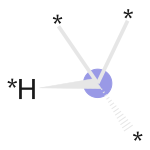

row=13, smiles=Br.C[C@H]1[C@H]2Cc3ccc(O)cc3[C@]1(C)CCN2CCc1ccccc1


[19:31:41] DEPRECATION WARNING: please use MorganGenerator


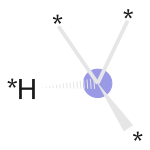

In [ ]:
# 3. 시각화
# 1) bit 하나 = 정확한 구조 1개 (X)-> 비슷한 구조들의 묶음 (hash)
# 같은 bit라도 여러 구조가 매핑될 수 있음 -> 그래서 여러 molecule에서 보는 게 중요
# 2) 중심 atom이 핵심 - 같은 구조라도: 중심 atom이 다르면 → 다른 bit
# 3) radius가 의미를 결정함 - radius=0 → atom 자체/ radius=1 → 1-hop 이웃/ radius=2 → functional group 수준 (보통 많이 씀)
for i, fname, bit_id, imp in fp_features[:3]:
    rows_with_bit = X_all.index[X_all[fname] == 1].tolist()[:3]

    print(f"\n=== {fname} / importance={imp:.4f} ===")

    for row_idx in rows_with_bit:
        smiles = valid_df.loc[row_idx, "canonical_smiles"]
        mol = Chem.MolFromSmiles(smiles)

        if mol is None:
            continue

        bit_info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048,
            bitInfo=bit_info
        )

        if bit_id in bit_info:
            print(f"row={row_idx}, smiles={smiles}")
            display(Draw.DrawMorganBit(mol, bit_id, bit_info))

            # 아래꺼 3X3 으로 출력하는거 안되나?

In [ ]:
# highlight) 보라색 = 중심 atom / 노란색 = 포함된 구조 ->  둘 합쳐서 그 bit의 의미
# 기본원자색) C: 회색, N: 파랑, O: 빨강, S: 노랑, H: 보통 생략

In [ ]:
# Feature importance vs. permutation importance vs. SHAP
# 실무에서 가장 흔한 조합: feature importance + SHAP (feature_importance → 빠른 스크리닝 /SHAP → 실제 해석)
# 현실적 패턴:
# STEP 1 feature importance → top feature 빠르게 확인
# STEP 2 SHAP → 방향 + 영향 해석
# STEP 3 (선택) permutation importance → 진짜 성능 영향 검증


# 1. Feature importance (RF, LightGBM 기본값)

# - 용도: 빠른 탐색
# - 어떤 feature가 대충 중요한지 / 모델 디버깅 / feature selection 초안
# - 장점: 빠름/바로 사용 가능
# - 단점: bias 있음(notion참고)/ 방향성 없음
# --> “초기 탐색용”

# 2. SHAP
# - 용도: 해석 (설명)
# - 장점: 방향성 있음 (+/-) / global + local 다 가능/시각화 좋음
# - 단점: 계산량 큼/약간 복잡
# --> “왜 중요한지 설명”용 (핵심)

# Random Forest: feature_importances_만 믿지 말기 / SHAP 또는 permutation importance 같이 보기
# LightGBM: SHAP 잘 맞음 / 보통 해석이 꽤 잘 나옴
# Logistic Regression: coef_ + SHAP 둘 다 가능/ descriptor 방향성 해석 쉬움
# Summary:
# Random Forest의 feature_importances_는 split 기반이라 연속형 변수, high-cardinality 변수, 상관된 변수에서 편향될 수 있습니다.
# 반면 SHAP은 예측값에 대한 각 feature의 기여도를 계산해서 방향성과 샘플별 설명까지 제공하므로, 보통 해석에는 훨씬 더 좋습니다.

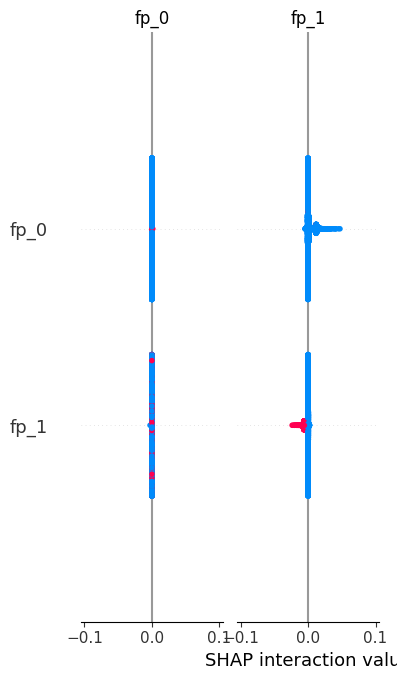

In [ ]:
# 2. SHAP: 방향성이 있음, 개별 샘플 설명 가능, 전역 요약 가능 (absolute SHAP)
# - 어떤 feature가 예측을 올렸는지
# - 어떤 feature가 예측을 내렸는지
# - 얼마나 크게 기여했는지

import shap

# SHAP 넘 오래 걸림-> sampling! (SHAP은 “통계적 패턴” 보는 거라서 전체 데이터 다 필요 없음, 300~1000개면 충분히 안정적)
X_sample = X_all.sample(min(500, len(X_all)), random_state=42)

# A. 전역 중요도 보기
explainer = shap.Explainer(rf_fp_desc_model, X_sample)
shap_values = explainer(X_sample)

print(shap_values.shape)    ## 필요???
shap.plots.beeswarm(shap_values)
# shap.plots.beeswarm(shap_values, max_display=20)

In [ ]:
# B. 막대그래프 중요도
shap.plots.bar(shap_values)

In [ ]:
# C. 특정 feature가 어떻게 작용하는지 - ex. FractionCSP3
shap.plots.scatter(shap_values[:, "FractionCSP3"])
#x축: FractionCSP3 값, y축: SHAP 값으로 해석 가능해요.
#SHAP 값이 크면 예측을 positive 방향으로 민다/ 작으면 negative 방향으로 민다

In [ ]:
# D. 개별 샘플 설명
shap.plots.waterfall(shap_values[0])
# 첫 번째 샘플에 대해 각 feature가 예측에 어떻게 기여했는지 보여줍니다.